## Project Overview

This project builds a machine learning pipeline to predict whether a Formula 1 driver will finish on the podium (top 3) in a given Grand Prix, using historical race data from the 2018–2024 seasons. The target variable is binary: **1 = podium finish, 0 = no podium**.

The full pipeline covers data loading and cleaning, feature engineering across seven conceptual groups, exploratory data analysis, and a comparison of three classification models evaluated on a held-out temporal test set.

**Dataset:** Kaggle F1 World Championship dataset (14 CSVs) spanning 149 races, 40 unique drivers, 16 constructors, and 31 circuits across seven seasons.
https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020

Make a folder data in the same level as model and install all the csv files there.

## Phase 1: Environment Setup & Data Loading

In [63]:
!pip install fastf1
#!pip install scikit-learn


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import fastf1
from pandas.core.window import rolling
from sklearn.linear_model import LogisticRegressionCV
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score
from sklearn.model_selection import cross_validate
from matplotlib.patches import Patch
from sklearn.calibration import calibration_curve


DATA_DIR = 'data/'

In [64]:
# Load all 14 Kaggle CSVs
races       = pd.read_csv(f'{DATA_DIR}races.csv')
results     = pd.read_csv(f'{DATA_DIR}results.csv')
qualifying  = pd.read_csv(f'{DATA_DIR}qualifying.csv')
drivers     = pd.read_csv(f'{DATA_DIR}drivers.csv')
constructors= pd.read_csv(f'{DATA_DIR}constructors.csv')
circuits    = pd.read_csv(f'{DATA_DIR}circuits.csv')
standings_d = pd.read_csv(f'{DATA_DIR}driver_standings.csv')
standings_c = pd.read_csv(f'{DATA_DIR}constructor_standings.csv')
pit_stops   = pd.read_csv(f'{DATA_DIR}pit_stops.csv')
lap_times   = pd.read_csv(f'{DATA_DIR}lap_times.csv')
sprint_results = pd.read_csv(f'{DATA_DIR}sprint_results.csv')

# Data Overview
for name, df in [('races', races), ('results', results), ('qualifying', qualifying),
                  ('drivers', drivers), ('constructors', constructors),
                  ('driver_standings', standings_d), ('constructor_standings', standings_c),
                  ('circuits', circuits), ('pit_stops', pit_stops)]:
    print(f'   {name:25s}: {df.shape[0]} x {df.shape[1]}')

   races                    : 1125 x 18
   results                  : 26759 x 18
   qualifying               : 10494 x 9
   drivers                  : 861 x 9
   constructors             : 212 x 5
   driver_standings         : 34863 x 7
   constructor_standings    : 13391 x 7
   circuits                 : 77 x 9
   pit_stops                : 11371 x 7


In [65]:
# Filtering races 2018 - 2024
races_filtered = races[(races['year'] >= 2018) & (races['year'] <= 2024)].copy()

print(f'Grand Prix races 2018–2024: {len(races_filtered)} races')
print(f'Seasons: {sorted(races_filtered["year"].unique().tolist())}')
print(f'\nRaces per season:\n{races_filtered.groupby("year").size().to_string()}\n\n')


races_filtered.head()

Grand Prix races 2018–2024: 149 races
Seasons: [2018, 2019, 2020, 2021, 2022, 2023, 2024]

Races per season:
year
2018    21
2019    21
2020    17
2021    22
2022    22
2023    22
2024    24




,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
976,989,2018,1,1,Australian Grand Prix,2018-03-25,05:10:00,http://en.wikipedia.org/wiki/2018_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
977,990,2018,2,3,Bahrain Grand Prix,2018-04-08,15:10:00,http://en.wikipedia.org/wiki/2018_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
978,991,2018,3,17,Chinese Grand Prix,2018-04-15,06:10:00,http://en.wikipedia.org/wiki/2018_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
979,992,2018,4,73,Azerbaijan Grand Prix,2018-04-29,12:10:00,http://en.wikipedia.org/wiki/2018_Azerbaijan_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
980,993,2018,5,4,Spanish Grand Prix,2018-05-13,13:10:00,http://en.wikipedia.org/wiki/2018_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [66]:
# Replace '\N' with NaN throughout
results = results.replace('\\N', np.nan)
qualifying = qualifying.replace('\\N', np.nan)
standings_d = standings_d.replace('\\N', np.nan)
standings_c = standings_c.replace('\\N', np.nan)

race_ids = races_filtered['raceId'].tolist()
results_filtered = results[results['raceId'].isin(race_ids)].copy()

print(f'Race entries 2018–2024: {len(results_filtered):,}')
print(f'Avg driver per race: {len(results_filtered)/len(races_filtered):.1f}')
print('\nResults Filterd:')
print(results_filtered[['raceId','driverId','constructorId','grid','position','positionOrder','points','statusId']].head(10).to_string())
results_filtered.info()

Race entries 2018–2024: 2,979
Avg driver per race: 20.0

Results Filterd:
       raceId  driverId  constructorId  grid position  positionOrder  points  statusId
23777     989        20              6     3        1              1    25.0         1
23778     989         1            131     1        2              2    18.0         1
23779     989         8              6     2        3              3    15.0         1
23780     989       817              9     8        4              4    12.0         1
23781     989         4              1    10        5              5    10.0         1
23782     989       830              9     4        6              6     8.0         1
23783     989       807              4     7        7              7     6.0         1
23784     989       822            131    15        8              8     4.0         1
23785     989       838              1    11        9              9     2.0         1
23786     989       832              4     9       10   

Podium rate: 15.0%  (447 podiums / 2979 entries)
Non-podium rate: 85.0%
Class ratio: ~1:6


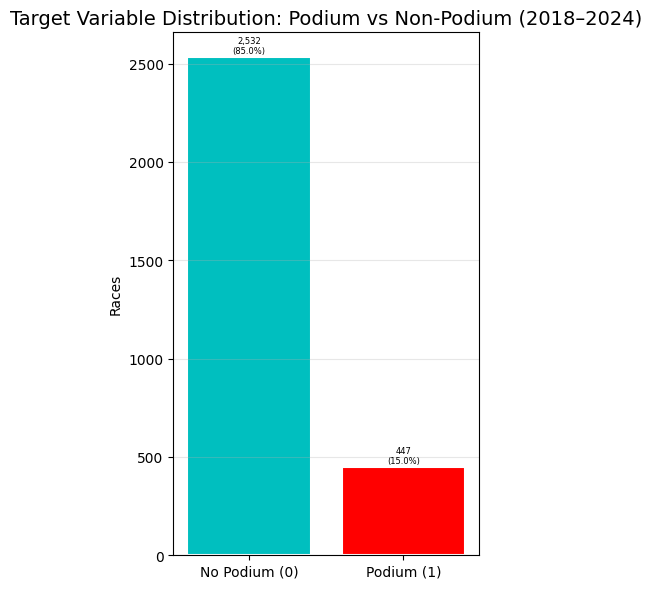

In [67]:
# Target variable (podium finish)
# results_filtered['positionOrder']
# results_filtered['grid']
# results_filtered['points']

results_filtered['podium'] = (results_filtered['positionOrder'] <= 3).astype(int)

# How balanced is our target?
podium_rate = results_filtered['podium'].mean()
print(f'Podium rate: {podium_rate:.1%}  ({results_filtered["podium"].sum()} podiums / {len(results_filtered)} entries)')
print(f'Non-podium rate: {1-podium_rate:.1%}')
print(f'Class ratio: ~1:{round((1-podium_rate)/podium_rate)}')

# Target distribution
fig, ax = plt.subplots(figsize=(4, 6))
counts = results_filtered['podium'].value_counts()
bars = ax.bar(['No Podium (0)', 'Podium (1)'], counts.values,
               color=['c', 'r'], edgecolor='w', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+20, f'{val:,}\n({val/len(results_filtered):.1%})', ha='center', fontsize=6)

ax.set_title('Target Variable Distribution: Podium vs Non-Podium (2018–2024)', fontsize=14)
ax.set_ylabel('Races')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()


In [68]:
def report(df, name):
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    print(f'\n{name} ({df.shape[0]:,} rows)')
    if len(nulls) == 0:
        print('  No nulls')
    else:
        for col, cnt in nulls.items():
            print(f'  {col}: {cnt} nulls')

report(results_filtered, 'results (filtered)')
report(qualifying[qualifying['raceId'].isin(race_ids)], 'qualifying (filtered)')
report(races_filtered, 'races (filtered)')


results (filtered) (2,979 rows)
  position: 401 nulls
  time: 1312 nulls
  milliseconds: 1312 nulls
  fastestLap: 134 nulls
  fastestLapTime: 134 nulls
  fastestLapSpeed: 134 nulls

qualifying (filtered) (2,976 rows)
  q1: 36 nulls
  q2: 781 nulls
  q3: 1525 nulls

races (filtered) (149 rows)
  No nulls


## Phase 2: Data Wrangling & Cleaning
Forming a master DataFrame

### 2.1 Decode DNF Status Codes
The `statusId` column has 100+ codes. We'll group them into 4 categories:
- `0` = Finished
- `1` = Mechanical DNF
- `2` = Accident / Collision DNF
- `3` = Disqualified / Did Not Start

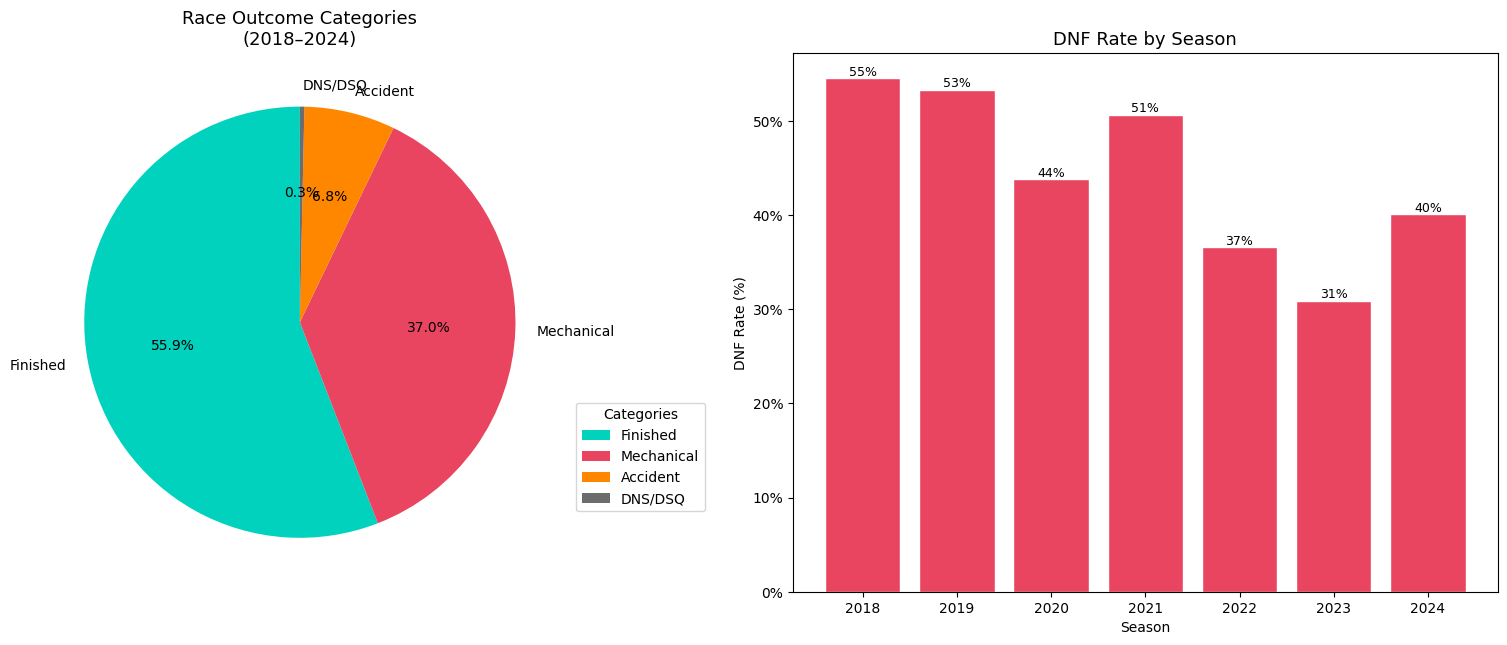

In [69]:
status = pd.read_csv(f'{DATA_DIR}status.csv')

mechanical = [
    'engine', 'gearbox', 'hydraulic', 'electrical', 'brakes', 'suspension',
    'clutch', 'transmission', 'oil', 'water', 'fuel', 'turbo', 'exhaust',
    'overheating', 'pneumatic', 'power unit', 'throttle', 'driveshaft',
    'differential', 'puncture', 'tyre', 'wheel', 'radiator', 'fire',
    'mechanical', 'technical', 'retired', 'withdrew', 'battery', 'electronics'
]

accident = [
    'accident', 'collision', 'spun off', 'crash', 'contact', 'damage',
    'wing', 'debris', 'barrier'
]

dns = ['disqualified', 'did not', 'not classified', 'excluded']

labels = {0: 'Finished', 1: 'Mechanical', 2: 'Accident', 3: 'DNS/DSQ'}

def classify_status(status_code):
  s = str(status_code).lower()
  if s == 'finished':
    return 0
  for k in dns:
    if k in s:
      return 3
  for k in accident:
    if k in s:
      return 2
  for k in mechanical:
    if k in s:
      return 1
  return 1

status['dnf_category'] = status['status'].apply(classify_status)

# Back to mainframe
results_filtered = results_filtered.merge(status[['statusId', 'status', 'dnf_category']], on='statusId', how='left')
results_filtered['dnf'] = (results_filtered['dnf_category'] > 0).astype(int)

# Calculate counts per category
counts = results_filtered['dnf_category'].value_counts()



fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Pie chart
colors = ['#00D2BE', '#e94560', '#FF8700', '#6c6c6c']
wedge_vals = [counts.get(i, 0) for i in range(4)]
wedges, texts, autotexts = axes[0].pie(wedge_vals, labels=[labels[i] for i in range(4)], autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Race Outcome Categories\n(2018–2024)', fontsize=13)
axes[0].legend(wedges, [labels[i] for i in range(4)], title="Categories", loc="center left", bbox_to_anchor=(1, -0.25, 0.5, 1))

# Bar chart by year
dnf_yr = results_filtered.merge(races_filtered[['raceId','year']], on='raceId').groupby('year')['dnf'].mean()
axes[1].bar(dnf_yr.index, dnf_yr.values * 100, color='#e94560', edgecolor='white')
axes[1].set_title('DNF Rate by Season', fontsize=13)
axes[1].set_ylabel('DNF Rate (%)')
axes[1].set_xlabel('Season')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, (yr, val) in enumerate(dnf_yr.items()):
    axes[1].text(yr, val*100 + 0.3, f'{val:.0%}', ha='center', fontsize=9)



### 2.2 Process Qualifying time
string to float

In [70]:
def convert_time(t):
  try:
    if pd.isna(t):
        return np.nan
    t = str(t).strip()
    if t.lower() in ('nan', '\\n', ''):
      return np.nan
    if ':' in t:
      p = t.split(':')
      return float(p[0])*60 + float(p[1])
    return float(t)
  except:
    return np.nan

qual_filtered = qualifying[qualifying['raceId'].isin(race_ids)].copy()
qual_filtered = qual_filtered.replace('\\N', np.nan)

for col in ['q1', 'q2', 'q3']:
  qual_filtered[f'{col}_sec'] = qual_filtered[col].apply(convert_time)

qual_filtered['best_qual_sec'] = qual_filtered[['q1_sec', 'q2_sec', 'q3_sec']].min(axis=1)

# Which quali did driver reaach?
# 1 valid time = Q1(0), 2 valid times = Q2(1), 3 valid times = Q3(2)
qual_filtered['qual_session'] = qual_filtered[['q1_sec', 'q2_sec', 'q3_sec']].count(axis=1) - 1
# Handle where a driver has no time set
qual_filtered['qual_session'] = qual_filtered['qual_session'].clip(lower=0)

qual_filtered['qual_position'] = pd.to_numeric(qual_filtered['position'])

print(f"Qualifying entries: {len(qual_filtered):,}")
print(f"Q3 participants: {qual_filtered['q3_sec'].notna().sum()} ({qual_filtered['q3_sec'].notna().mean():.1%})")
print(f"Best qual time range: {qual_filtered['best_qual_sec'].min():.3f}s – {qual_filtered['best_qual_sec'].max():.3f}s\n\n")

print(qual_filtered[['raceId','driverId','qual_position','q1_sec','q2_sec','q3_sec','best_qual_sec','qual_session']].head(8).to_string())

Qualifying entries: 2,976
Q3 participants: 1451 (48.8%)
Best qual time range: 53.377s – 141.611s


      raceId  driverId  qual_position  q1_sec  q2_sec  q3_sec  best_qual_sec  qual_session
7516     989         1              1  82.824  82.051  81.164         81.164             2
7517     989         8              2  83.096  82.507  81.828         81.828             2
7518     989        20              3  83.348  81.944  81.838         81.838             2
7519     989       830              4  83.483  82.416  81.879         81.879             2
7520     989       817              5  83.494  82.897  82.152         82.152             2
7521     989       825              6  83.909  83.300  83.187         83.187             2
7522     989       154              7  83.671  83.468  83.339         83.339             2
7523     989       807              8  83.782  83.544  83.532         83.532             2


### 2.3 Building the Mainframe

Merging all tables using raceId and driverId

In [71]:
# Results + race info
master = results_filtered.merge(races_filtered[['raceId', 'year', 'round', 'name', 'date', 'circuitId']], on='raceId', how='inner')

# Constructor info
master = master.merge(constructors[['constructorId','name']].rename(columns={'name': 'constructor_name'}), on='constructorId', how='left')

# Driver info
d_clean = drivers.copy()
d_clean['driver_name'] = d_clean['forename'] + ' ' + d_clean['surname']
master = master.merge(d_clean[['driverId', 'driver_name', 'driverRef', 'nationality', 'dob']], on='driverId', how='left')

# Qualifying
master = master.merge(qual_filtered[['raceId', 'driverId', 'qual_position', 'best_qual_sec', 'qual_session', 'q1_sec', 'q2_sec', 'q3_sec']], on=['raceId', 'driverId'], how='left')

# Circuit
master = master.merge(circuits[['circuitId', 'circuitRef', 'location', 'country', 'lat', 'lng', 'alt']], on='circuitId', how='left')

master['date'] = pd.to_datetime(master['date'])
master = master.sort_values(['date', 'grid']).reset_index(drop=True)

print(f"Master shape: {master.shape[0]:,} rows × {master.shape[1]} columns")
print(f"Date range: {master['date'].min().date()} - {master['date'].max().date()}")
print(f"Unique drivers: {master['driverId'].nunique()}")
print(f"Unique teams: {master['constructorId'].nunique()}")
print(f"Unique circuits: {master['circuitId'].nunique()}")

Master shape: 2,979 rows × 44 columns
Date range: 2018-03-25 - 2024-12-08
Unique drivers: 40
Unique teams: 16
Unique circuits: 31


### 2.4 Handle Nulls & Type Conversions

In [72]:
for col in ['grid', 'positionOrder', 'points', 'qual_position', 'best_qual_sec', 'lat', 'lng', 'alt']:
  master[col] = pd.to_numeric(master[col], errors='coerce')

# Pit lane start treat as last
master['grid'] = master['grid'].replace(0,20).fillna(20)

# Didnt qualify
master['qual_position'] = master['qual_position'].fillna(20)

# DNFs -> 21 behind last
master['positionOrder'] = master['positionOrder'].fillna(21)

# Alt median
master['alt'] = master['alt'].fillna(master['alt'].median())

# Age
master['dob'] = pd.to_datetime(master['dob'])
master['age'] = (master['date'] - master['dob']).dt.days / 365.25
master.drop(columns=['dob'], inplace=True)

######## DROP #########
drop_cols = ['time', 'milliseconds', 'fastestLap', 'fastestLapTime',
             'fastestLapSpeed', 'rank', 'number', 'position', 'laps',
             'positionText', 'resultId', 'statusId', 'q1_sec', 'q2_sec', 'q3_sec']
master.drop(columns=[c for c in drop_cols if c in master.columns], inplace=True)

# Null Check
n = master.isnull().sum()
n = n[n>0]
if len(n) == 0:
  print(f"None")
else:
  for c, cnt in n.items():
    print(f"  {c}: {cnt}({cnt/len(master):.1%})")



  best_qual_sec: 39(1.3%)
  qual_session: 3(0.1%)


### 2.5 Pre-Race Championship Standings

Standing before the current race

In [73]:
race_seq = races_filtered[['raceId', 'year', 'round']].sort_values(['year', 'round']).copy().reset_index(drop=True)
race_seq['prev_raceId'] = race_seq['raceId'].shift(1).astype('Int64')

race_seq.loc[race_seq['round'] == 1, 'prev_raceId'] = pd.NA

# Driver postion before race
drv_std = standings_d.copy()
for col in ['driverId', 'points', 'position', 'wins']:
  drv_std[col] = pd.to_numeric(drv_std[col], errors='coerce')

drv_std_prev = (drv_std.merge(race_seq[['raceId', 'prev_raceId']], left_on='raceId', right_on='prev_raceId', how='inner')
    [['raceId_y', 'driverId', 'points', 'position', 'wins']]
    .rename(columns={
        'raceId_y':'raceId',
        'points':'champ_points_before',
        'position':'champ_pos_before',
        'wins':'champ_wins_before'
    }))

# Constructors standings
con_std = standings_c.copy()
for col in ['constructorId', 'points', 'position']:
    con_std[col] = pd.to_numeric(con_std[col], errors='coerce')

con_std_prev = (con_std.merge(race_seq[['raceId', 'prev_raceId']], left_on='raceId', right_on='prev_raceId', how='inner')
    [['raceId_y', 'constructorId', 'points', 'position']]
    .rename(columns={
        'raceId_y':'raceId',
        'points':'con_points_before',
        'position':'con_pos_before'
    })
)

# Merge to master
master = master.merge(drv_std_prev, on=['raceId', 'driverId'], how='left')
master = master.merge(con_std_prev, on=['raceId', 'constructorId'], how='left')

for col in ['champ_points_before', 'champ_pos_before', 'con_points_before']:
  master[col] = master[col].fillna(0)

for col in ['champ_pos_before', 'con_pos_before']:
  master[col] = master[col].fillna(20)

# no wins is 0
master['champ_wins_before'] = master['champ_wins_before'].fillna(0)
# Pos 0 dosent exit -> 20
master['champ_pos_before'] = master['champ_pos_before'].replace(0, 20)


# Sanity check
print("Championship standings merged.")
print(f"champ_points_before : min={master['champ_points_before'].min():.0f}  "f"max={master['champ_points_before'].max():.0f}")
print(f"champ_pos_before    : min={master['champ_pos_before'].min():.0f}  "f"max={master['champ_pos_before'].max():.0f}")
print(f"con_pos_before      : min={master['con_pos_before'].min():.0f}  "f"max={master['con_pos_before'].max():.0f}")

nulls = master[['champ_points_before', 'champ_pos_before', 'champ_wins_before', 'con_points_before', 'con_pos_before']].isnull().sum()
print(f"\nNull check on standings columns:")
for col, cnt in nulls.items():
    print(f"  {col}: {cnt}")

print(f"\nFinal master shape: {master.shape[0]:,} rows × {master.shape[1]} columns")
print(f"\nAll columns:")
for i, col in enumerate(master.columns):
    print(f"  {i:2d}. {col}")

Championship standings merged.
champ_points_before : min=0  max=549
champ_pos_before    : min=1  max=23
con_pos_before      : min=1  max=20

Null check on standings columns:
  champ_points_before: 0
  champ_pos_before: 0
  champ_wins_before: 0
  con_points_before: 0
  con_pos_before: 0

Final master shape: 2,979 rows × 34 columns

All columns:
   0. raceId
   1. driverId
   2. constructorId
   3. grid
   4. positionOrder
   5. points
   6. podium
   7. status
   8. dnf_category
   9. dnf
  10. year
  11. round
  12. name
  13. date
  14. circuitId
  15. constructor_name
  16. driver_name
  17. driverRef
  18. nationality
  19. qual_position
  20. best_qual_sec
  21. qual_session
  22. circuitRef
  23. location
  24. country
  25. lat
  26. lng
  27. alt
  28. age
  29. champ_points_before
  30. champ_pos_before
  31. champ_wins_before
  32. con_points_before
  33. con_pos_before


## Phase 3: Feature Engineering


7 Features group
1. Qualifying gap to pole
2. Driver form (recent finished EWMA)
3. Constructors Form (Team momemtum and DNF rate)
4. Driver Track affinity (Hist perforemance)
5. Track Type
6. Home Race
7. Winning Mindset (pts diffrence between race lead and driver)

### 3.1 Qualifying Gap to pole
Normalize each race as percentage gap to pole

In [74]:
pole_times = (master[master['qual_position'] == 1].groupby('raceId')['best_qual_sec'].min().rename('pole_time'))

master = master.merge(pole_times, on='raceId', how='left')

# % gap (driver time - pole time)/ pole time * 100
master['qual_gap_to_pole_pct'] = (master['best_qual_sec'] - master['pole_time']) / master['pole_time'] * 100

# Handle driver without a qual time
r_median = master.groupby('raceId')['qual_gap_to_pole_pct'].transform('median')
master['qual_gap_to_pole_pct'] = master['qual_gap_to_pole_pct'].fillna(r_median)

# Sanity check
print("qual_gap_to_pole_pct summary:")
print(master['qual_gap_to_pole_pct'].describe().round(4).to_string())
print(f"\nTop 5 closest to pole:")
print(master.nsmallest(5, 'qual_gap_to_pole_pct')[['driver_name','year','name','qual_position','qual_gap_to_pole_pct']].to_string())

qual_gap_to_pole_pct summary:
count    2979.0000
mean        1.9693
std         2.2446
min        -1.0590
25%         0.7952
50%         1.6090
75%         2.5153
max        45.5956

Top 5 closest to pole:
           driver_name  year                  name  qual_position  qual_gap_to_pole_pct
1801    Max Verstappen  2022    British Grand Prix            2.0             -1.058988
223   Sebastian Vettel  2018  Hungarian Grand Prix            4.0             -0.972629
2023    Max Verstappen  2022  São Paulo Grand Prix            2.0             -0.740793
2027      Carlos Sainz  2022  São Paulo Grand Prix            5.0             -0.728189
2025   Charles Leclerc  2022  São Paulo Grand Prix           10.0             -0.644167


### 3.2 Driver form
Capture last 5 races to get momentum

In [75]:
master['qual_gap_to_pole_pct'] = master['qual_gap_to_pole_pct'].clip(lower=0)

# Sort by date to ensure the rolling window is chronological
master = master.sort_values(['year', 'round', 'grid']).reset_index(drop=True)

# EWMA of last 5 race
master['driver_form_5'] = (master.groupby('driverId')['positionOrder'].transform(lambda x: x.shift(1).ewm(span=5).mean()))

# Rolling mean last 3 races
master['driver_form_3'] = (master.groupby('driverId')['positionOrder'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean()))

# handle condition for first races of career
master['driver_form_5'] = master['driver_form_5'].fillna(10)
master['driver_form_3'] = master['driver_form_3'].fillna(10)


# Sanity check
print("driver_form_5 summary:")
print(master['driver_form_5'].describe().round(3).to_string())

ham = master[(master['driverRef']=='hamilton') & (master['year']==2021)]
print(f"\nHamilton 2021 avg driver_form_5: {ham['driver_form_5'].mean():.2f} expected 3 to 5")

driver_form_5 summary:
count    2979.000
mean       10.450
std         4.211
min         1.000
25%         7.341
50%        10.934
75%        13.704
max        20.000

Hamilton 2021 avg driver_form_5: 3.41 expected 3 to 5


### 3.3 Constructor form
Capture team form

In [76]:

master['constructor_form_5'] = (master.groupby('constructorId')['positionOrder'].transform(lambda x: x.shift(1).ewm(span=5).mean())).fillna(10)

# DNF rates
master['constructor_reliability'] = (master.groupby('constructorId')['dnf'].transform(lambda x: x.shift(1).rolling(10, min_periods=3).mean())).fillna(master['dnf'].mean())


print("constructor_form_5 summary:")
print(master['constructor_form_5'].describe().round(3).to_string())
print(f"\nconstructor_reliability summary:")
print(master['constructor_reliability'].describe().round(3).to_string())

# Red Bull 2023 should be very reliable
rb23 = master[(master['constructor_name']=='Red Bull') & (master['year']==2023)]
print(f"\nRed Bull 2023 avg reliability (DNF rate): {rb23['constructor_reliability'].mean():.3f}")
print(f"Red Bull 2023 avg form: {rb23['constructor_form_5'].mean():.2f}")

constructor_form_5 summary:
count    2979.000
mean       10.485
std         4.200
min         1.330
25%         7.209
50%        11.042
75%        13.900
max        19.000

constructor_reliability summary:
count    2979.000
mean        0.443
std         0.274
min         0.000
25%         0.200
50%         0.400
75%         0.700
max         1.000

Red Bull 2023 avg reliability (DNF rate): 0.059
Red Bull 2023 avg form: 3.58


### 3.4 Driver favorite track affinity

In [77]:
master = master.sort_values(['driverRef', 'circuitRef', 'date']).reset_index(drop=True)

master['driver_circuit_avg'] = (master.groupby(['driverRef', 'circuitId'])['positionOrder'].transform(lambda x: x.shift(1).expanding().mean())).fillna(master['driver_form_5'])

master = master.sort_values(['date', 'raceId', 'grid']).reset_index(drop=True)

print("driver_circuit_avg summary:")
print(master['driver_circuit_avg'].describe().round(3).to_string())

# Top driver-circuit combos (best avg position = lowest number)
top_combos = (master.groupby(['driver_name','circuitRef'])['driver_circuit_avg'].mean().sort_values().head(10))
print("\nTop 10 driver-circuit affinities (lowest avg position = dominance):")
print(top_combos.round(2).to_string())

driver_circuit_avg summary:
count    2979.000
mean       10.499
std         4.618
min         1.000
25%         7.000
50%        10.798
75%        14.000
max        20.000

Top 10 driver-circuit affinities (lowest avg position = dominance):
driver_name       circuitRef 
Max Verstappen    vegas          1.09
Lewis Hamilton    istanbul       1.25
                  sochi          1.35
                  catalunya      1.42
                  portimao       1.55
                  hungaroring    1.62
                  ricard         1.64
Max Verstappen    jeddah         1.88
Sebastian Vettel  villeneuve     1.95
Max Verstappen    losail         2.02


### 3.5 Track Type

In [78]:
street_circuits = {'monaco', 'baku', 'singapore', 'jeddah', 'miami', 'vegas', 'losail', 'marina_bay'}
master['is_street_circuit'] = master['circuitRef'].isin(street_circuits).astype(int)

# High alt threshhold 1000m
master['is_high_altitude'] = (master['alt'] > 1000).astype(int)


drs_zones = {
    'monza': 3, 'baku': 3, 'spa': 2, 'shanghai': 3,
    'bahrain': 3, 'jeddah': 3, 'miami': 3, 'vegas': 3,
    'albert_park': 4, 'losail': 2, 'suzuka': 1,
    'monaco': 1, 'singapore': 3, 'hungaroring': 1,
    'interlagos': 2, 'yas_marina': 3, 'silverstone': 2,
    'red_bull_ring': 3, 'hockenheimring': 2, 'paul_ricard': 2,
    'catalunya': 2, 'villeneuve': 3, 'nurburgring': 1,
    'imola': 2, 'portimao': 2, 'mugello': 2, 'istanbul': 2,
    'zandvoort': 2, 'rodriguez': 2, 'americas': 2,
    'marina_bay': 3
}

master['drs_zones'] = master['circuitRef'].map(drs_zones).fillna(2).astype(int)


print("Track feature distributions:")
print(f"  Street circuits:  {master['is_street_circuit'].sum()} entries "
      f"({master['is_street_circuit'].mean():.1%} of races)")
print(f"  High altitude:    {master['is_high_altitude'].sum()} entries "
      f"({master['is_high_altitude'].mean():.1%} of races)")
print(f"  DRS zones range:  {master['drs_zones'].min()} – {master['drs_zones'].max()}")
print(f"\nStreet circuits in dataset:")
print(master[master['is_street_circuit']==1]['circuitRef'].unique())

Track feature distributions:
  Street circuits:  580 entries (19.5% of races)
  High altitude:    120 entries (4.0% of races)
  DRS zones range:  1 – 4

Street circuits in dataset:
['baku' 'monaco' 'marina_bay' 'losail' 'jeddah' 'miami' 'vegas']


### 3.6 Home Race

In [79]:
# Nationality to country
nationality_country_map = {
    'British'     : ['UK', 'Great Britain', 'United Kingdom'],
    'German'      : ['Germany'],
    'Spanish'     : ['Spain'],
    'Finnish'     : ['Finland'],
    'Australian'  : ['Australia'],
    'Canadian'    : ['Canada'],
    'Brazilian'   : ['Brazil'],
    'Dutch'       : ['Netherlands'],
    'Mexican'     : ['Mexico'],
    'French'      : ['France'],
    'Monegasque'  : ['Monaco'],
    'Italian'     : ['Italy'],
    'Japanese'    : ['Japan'],
    'American'    : ['USA', 'United States'],
    'Danish'      : ['Denmark'],
    'Thai'        : ['Thailand'],
    'Chinese'     : ['China'],
    'Austrian'    : ['Austria'],
    'Belgian'     : ['Belgium'],
    'Swiss'       : ['Switzerland'],
    'Polish'      : ['Poland'],
    'Russian'     : ['Russia'],
    'Swedish'     : ['Sweden'],
}

def get_country(n):
  h_c = nationality_country_map.get(n['nationality'], [])
  return int(n['country'] in h_c)

master['home_race'] = master.apply(get_country, axis=1)

# Verify
print(f"Home race entries: {master['home_race'].sum()} ({master['home_race'].mean():.1%})")
print(master[master['home_race']==1][['driver_name','nationality','country','year']].drop_duplicates().head(12).to_string())

# Does home race actually help? Quick check
home_podium = master[master['home_race']==1]['podium'].mean()
away_podium = master[master['home_race']==0]['podium'].mean()
print(f"\nPodium rate at home races: {home_podium:.1%}")
print(f"Podium rate at away races: {away_podium:.1%}")
print(f"Home advantage: {(home_podium - away_podium)*100:+.2f}")

Home race entries: 96 (3.2%)
           driver_name nationality    country  year
7     Daniel Ricciardo  Australian  Australia  2018
87     Fernando Alonso     Spanish      Spain  2018
88        Carlos Sainz     Spanish      Spain  2018
113    Charles Leclerc  Monegasque     Monaco  2018
136       Lance Stroll    Canadian     Canada  2018
149    Romain Grosjean      French     France  2018
150       Esteban Ocon      French     France  2018
153       Pierre Gasly      French     France  2018
180     Lewis Hamilton     British         UK  2018
200   Sebastian Vettel      German    Germany  2018
206    Nico Hülkenberg      German    Germany  2018
257  Stoffel Vandoorne     Belgian    Belgium  2018

Podium rate at home races: 18.8%
Podium rate at away races: 14.9%
Home advantage: +3.87


### 3.7 Winning MindSet
Championship leader starting P1 is the biggest driver for a driver

In [80]:
# Grid x championship, low val = better (front grid + good standing )
master['grid_x_champ'] = master['grid'] * master['champ_pos_before']

# Diff with leader, per race = leader pts - driver pts
rl_pts = master.groupby('raceId')['champ_points_before'].transform('max')
master['points_gap_to_leader'] = rl_pts - master['champ_points_before']

master['reached_q3'] = (master['qual_session'] >= 2).astype(int)

print("Interaction features added:")
print(f"  grid_x_champ range: {master['grid_x_champ'].min():.0f} – {master['grid_x_champ'].max():.0f}")
print(f"  points_gap_to_leader range: {master['points_gap_to_leader'].min():.0f} – {master['points_gap_to_leader'].max():.0f}")
print(f"  reached_q3 rate: {master['reached_q3'].mean():.1%}  (expect 50%)")


Interaction features added:
  grid_x_champ range: 1 – 437
  points_gap_to_leader range: 0 – 548
  reached_q3 rate: 48.7%  (expect 50%)


### 3.8 Final Feature Set

In [81]:
# Target and Features columns

FEATURE_COLS = [
    # Qualifying & grid
    'grid',
    'qual_position',
    'qual_gap_to_pole_pct',
    'qual_session',
    'reached_q3',

    # Driver form
    'driver_form_5',
    'driver_circuit_avg',
    'age',

    # Constructor form & reliability
    'constructor_form_5',
    'constructor_reliability',

    # Championship standings
    'champ_points_before',
    'champ_pos_before',
    'champ_wins_before',
    'con_points_before',
    'con_pos_before',

    # Track features
    'is_street_circuit',
    'is_high_altitude',
    'drs_zones',
    'alt',

    # Contextual
    'home_race',
    'round',
    'grid_x_champ',
    'points_gap_to_leader',
]

TARGET_COL = 'podium'

# Fill remaining nulls in qual_session with 0 (Q1)
master['qual_session'] = master['qual_session'].fillna(0)


print(f"\nFinal modelling dataset: {master.shape[0]:,} rows × {len(FEATURE_COLS)} features")
print(f"Podium rate: {master[TARGET_COL].mean():.1%}")


Final modelling dataset: 2,979 rows × 23 features
Podium rate: 15.0%


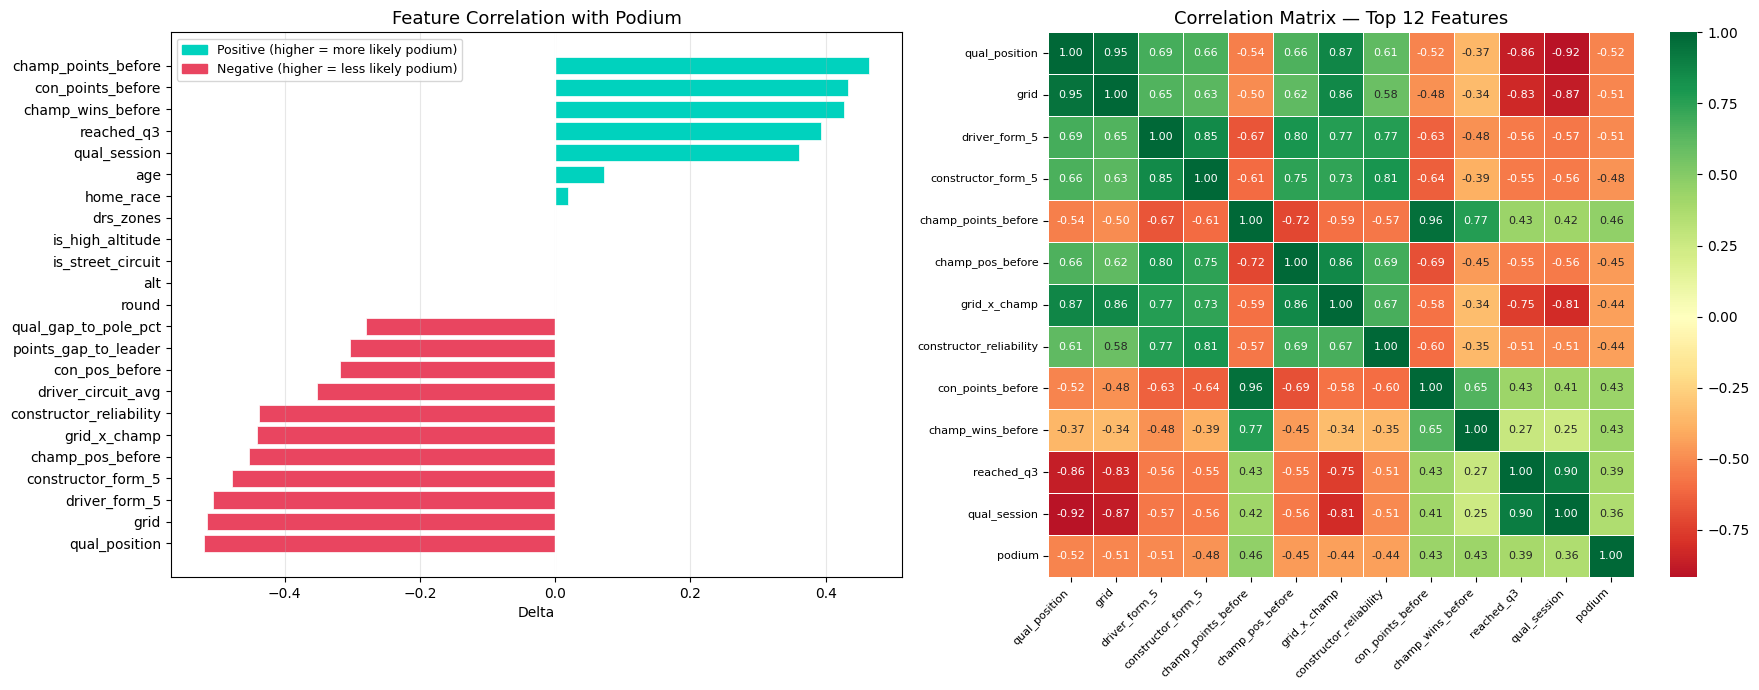

In [82]:
corr = master[FEATURE_COLS + [TARGET_COL]].corr()

# Calculate target_corr needed for the plot
target_corr = corr[TARGET_COL].drop(TARGET_COL).sort_values()

# Heatmap of top correlated features
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# correlation with target
colors = ['#e94560' if v < 0 else '#00D2BE' for v in target_corr.values]
axes[0].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].axvline(0, color='white', linewidth=1)
axes[0].set_title('Feature Correlation with Podium', fontsize=13)
axes[0].set_xlabel('Delta')
axes[0].grid(axis='x', alpha=0.3)
red_patch = mpatches.Patch(color='#e94560', label='Negative (higher = less likely podium)')
teal_patch = mpatches.Patch(color='#00D2BE', label='Positive (higher = more likely podium)')
axes[0].legend(handles=[teal_patch, red_patch], fontsize=9)

# Correlation heatmap
top_feats = target_corr.abs().nlargest(12).index.tolist() + [TARGET_COL]
corr_subset = master[top_feats].corr()
mask = np.zeros_like(corr_subset, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(corr_subset, ax=axes[1], cmap='RdYlGn', center=0, annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 8})
axes[1].set_title('Correlation Matrix — Top 12 Features', fontsize=13)
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(axes[1].get_yticklabels(), fontsize=8)
plt.tight_layout()

## Phase 4: Exploratory Data Analysis & Visualization

**Questions answered:**
1. Who dominated podiums 2018–2024?
2. How strongly does grid position predict podium?
3. Does driver form actually predict outcomes?
4. Which circuits are hardest to podium at?
5. How has constructor dominance shifted across seasons?
6. Does qualifying session reached separate podium finishers?

In [83]:
TEAM_COLORS = {
    'Mercedes': '#00D2BE',
    'Red Bull': '#0600EF',
    'Ferrari': '#DC0000',
    'McLaren': '#FF8700',
    'Alpine': '#0090FF',
    'AlphaTauri': '#2B4562',
    'Aston Martin': '#006F62',
    'Williams': '#005AFF',
    'Alfa Romeo': '#900000',
    'Haas': '#FFFFFF',
}

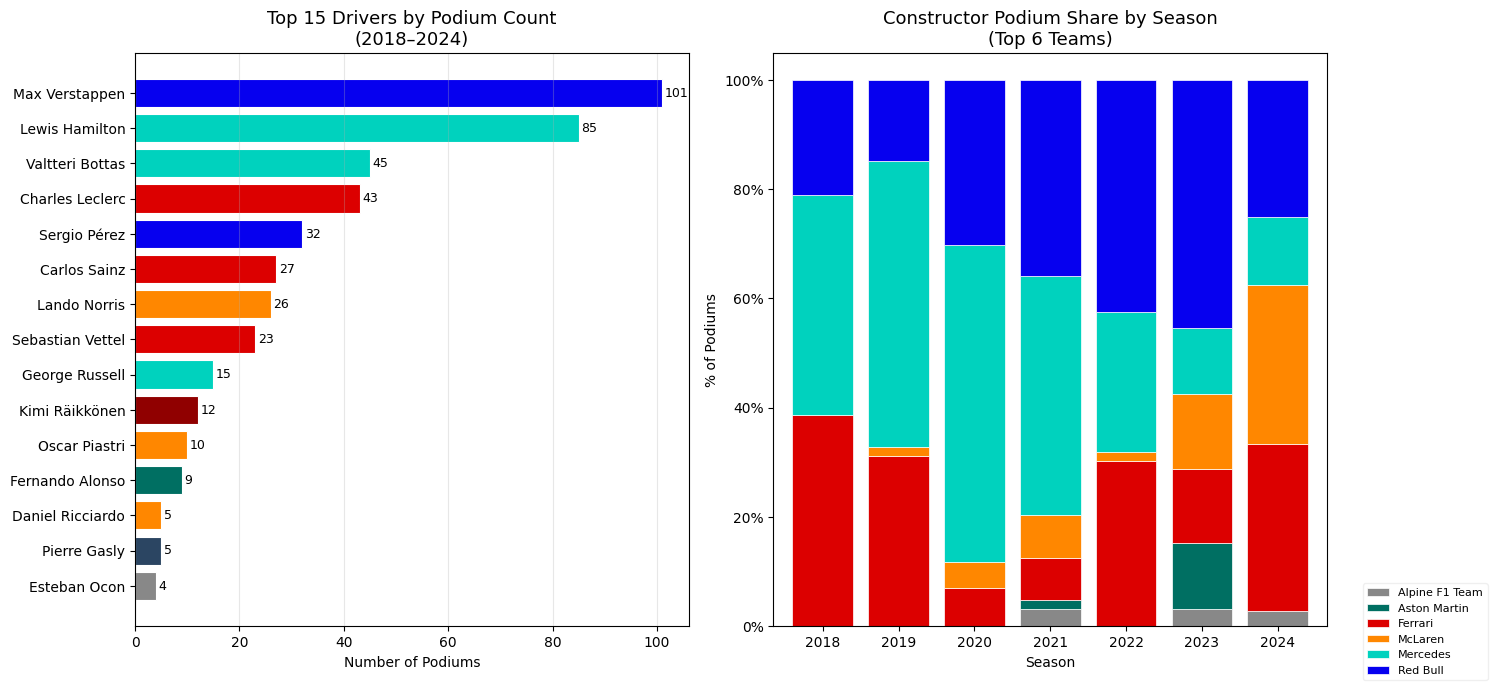

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Top 15 drivers by podium count
driver_podiums = (master[master['podium']==1].groupby('driver_name').size().sort_values(ascending=True).tail(15))

# Color by constructor
driver_team = master.groupby('driver_name')['constructor_name'].agg(lambda x: x.mode()[0])
bar_colors = []
for d in driver_podiums.index:
    team = driver_team.get(d, 'Other')
    bar_colors.append(TEAM_COLORS.get(team, '#888888'))

bars = axes[0].barh(driver_podiums.index, driver_podiums.values,color=bar_colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, driver_podiums.values):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)

axes[0].set_title('Top 15 Drivers by Podium Count\n(2018–2024)', fontsize=13)
axes[0].set_xlabel('Number of Podiums')
axes[0].grid(axis='x', alpha=0.3)

# Constructor podium share by season
top_teams = (master[master['podium']==1].groupby('constructor_name').size().sort_values(ascending=False).head(6).index.tolist())

team_season = (master[master['podium']==1].groupby(['year','constructor_name']).size().reset_index(name='podiums'))
team_season = team_season[team_season['constructor_name'].isin(top_teams)]

pivot = team_season.pivot(index='year', columns='constructor_name', values='podiums').fillna(0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

colors_teams = [TEAM_COLORS.get(t, '#888888') for t in pivot_pct.columns]
pivot_pct.plot(kind='bar', stacked=True, ax=axes[1], color=colors_teams, edgecolor='white', linewidth=0.5, width=0.8)
axes[1].set_title('Constructor Podium Share by Season\n(Top 6 Teams)', fontsize=13)
axes[1].set_ylabel('% of Podiums')
axes[1].set_xlabel('Season')
axes[1].legend(loc='center right', fontsize=8, framealpha=0.3, bbox_to_anchor=(1.3, -0.01))
axes[1].set_xticklabels(pivot_pct.index, rotation=0)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()

### 4.2 Grid Position vs Podium Rate

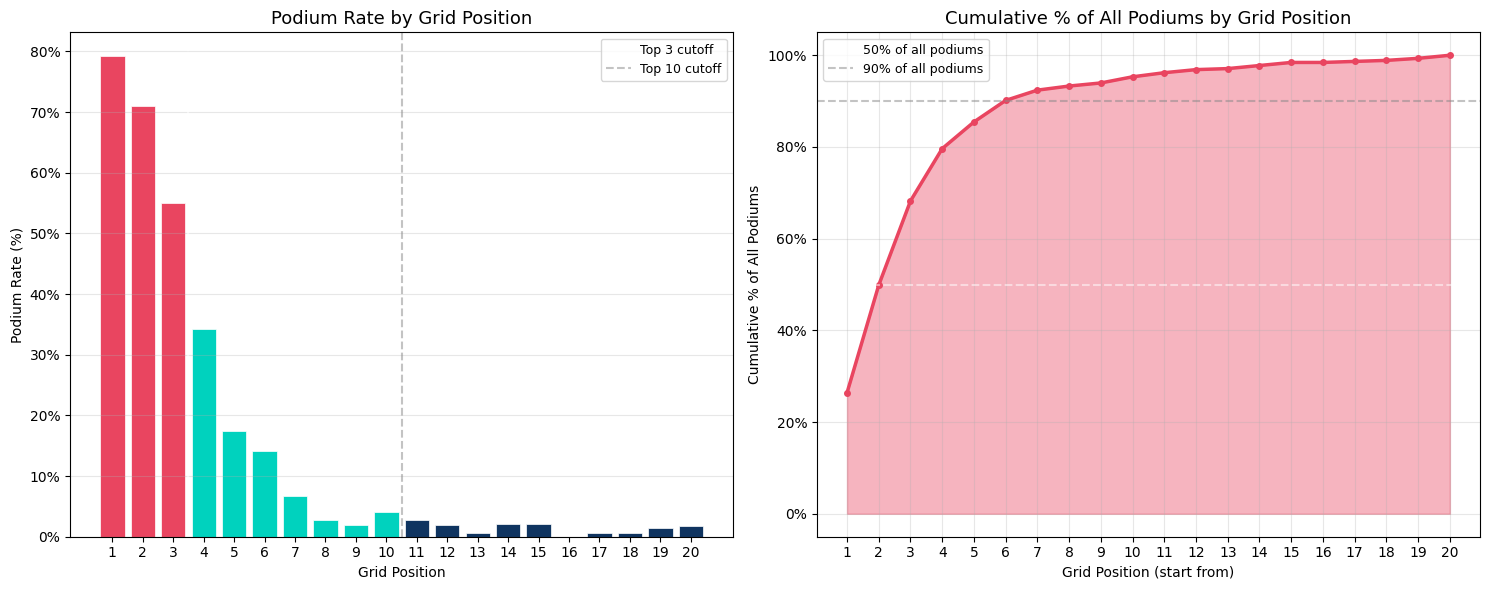

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Podium rate per grid position
grid_podium = (master.groupby('grid')['podium'].agg(['mean', 'count']).reset_index().rename(columns={'mean':'podium_rate', 'count':'entries'}))
grid_podium = grid_podium[grid_podium['grid'] <= 20]
grid_podium['podium_rate_pct'] = grid_podium['podium_rate'] * 100

# Bar chart
bar_cols = ['#e94560' if g <= 3 else '#00D2BE' if g <= 10 else '#0f3460' for g in grid_podium['grid']]
axes[0].bar(grid_podium['grid'], grid_podium['podium_rate_pct'], color=bar_cols, edgecolor='white', linewidth=0.5)
axes[0].set_title('Podium Rate by Grid Position', fontsize=13)
axes[0].set_xlabel('Grid Position')
axes[0].set_ylabel('Podium Rate (%)')
axes[0].set_xticks(range(1, 21))
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].axvline(3.5, color='white', linestyle='--', alpha=0.5, label='Top 3 cutoff')
axes[0].axvline(10.5, color='#888888', linestyle='--', alpha=0.5, label='Top 10 cutoff')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Cumulative podium probability from front
cum_data = grid_podium.sort_values('grid').copy()
cum_data['cum_share'] = (cum_data['podium_rate'] * cum_data['entries']).cumsum() / master['podium'].sum() * 100
axes[1].fill_between(cum_data['grid'], cum_data['cum_share'], alpha=0.4, color='#e94560')
axes[1].plot(cum_data['grid'], cum_data['cum_share'],color='#e94560', linewidth=2.5, marker='o', markersize=4)
axes[1].axhline(50, color='white', linestyle='--', alpha=0.5, label='50% of all podiums')
axes[1].axhline(90, color='#888888', linestyle='--', alpha=0.5, label='90% of all podiums')
axes[1].set_title('Cumulative % of All Podiums by Grid Position', fontsize=13)
axes[1].set_xlabel('Grid Position (start from)')
axes[1].set_ylabel('Cumulative % of All Podiums')
axes[1].set_xticks(range(1, 21))
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()


### 4.3 Driver Form Distribution: Podium vs Non-Podium

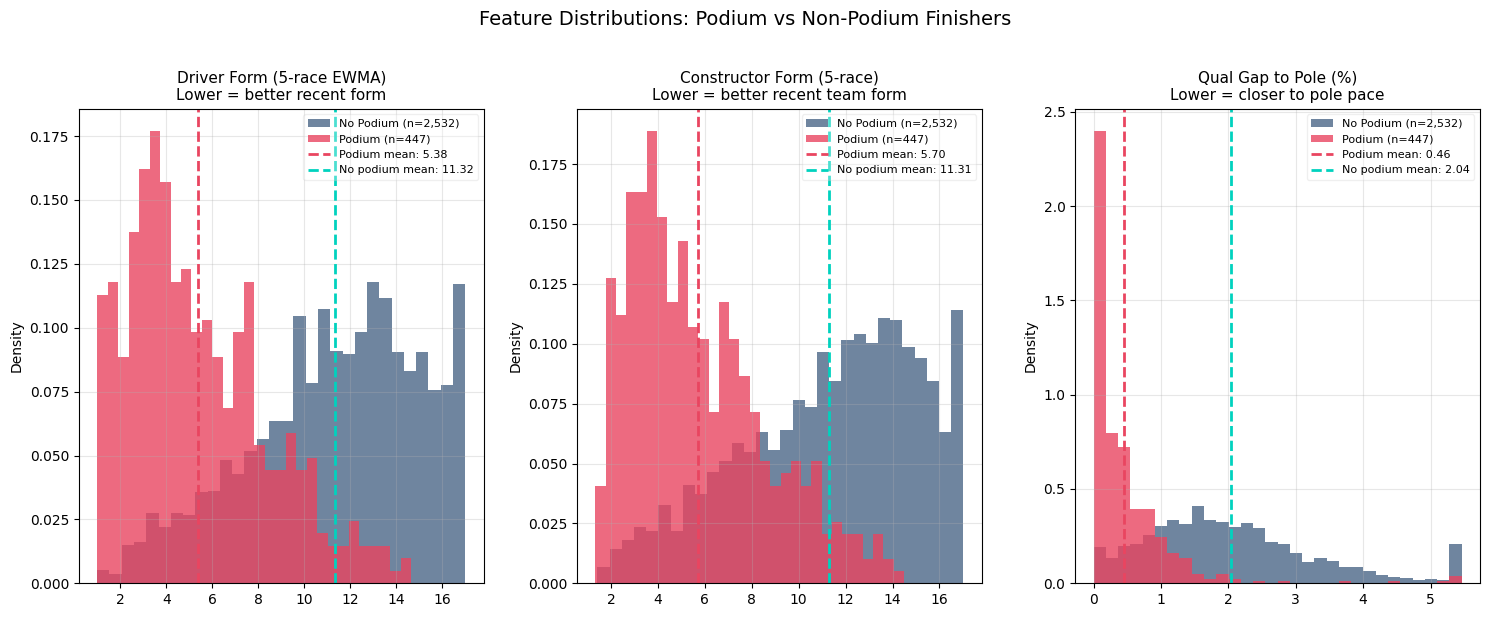

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

features_to_plot = [ ('driver_form_5',        'Driver Form (5-race EWMA)',    'Lower = better recent form'),
                    ('constructor_form_5',   'Constructor Form (5-race)',    'Lower = better recent team form'),
                    ('qual_gap_to_pole_pct', 'Qual Gap to Pole (%)',         'Lower = closer to pole pace'),
]

for ax, (feat, title, subtitle) in zip(axes, features_to_plot):
    podium_vals    = master[master['podium']==1][feat]
    no_podium_vals = master[master['podium']==0][feat]

    # Clip
    clip_max = master[feat].quantile(0.97)
    podium_vals = podium_vals.clip(upper=clip_max)
    no_podium_vals = no_podium_vals.clip(upper=clip_max)

    ax.hist(no_podium_vals, bins=30, alpha=0.6, color='#0f3460', label=f'No Podium (n={len(no_podium_vals):,})', density=True)
    ax.hist(podium_vals, bins=30, alpha=0.8, color='#e94560', label=f'Podium (n={len(podium_vals):,})', density=True)

    # Mean lines
    ax.axvline(podium_vals.mean(),    color='#e94560', linestyle='--', linewidth=2, label=f'Podium mean: {podium_vals.mean():.2f}')
    ax.axvline(no_podium_vals.mean(), color='#00D2BE', linestyle='--', linewidth=2, label=f'No podium mean: {no_podium_vals.mean():.2f}')

    ax.set_title(f'{title}\n{subtitle}', fontsize=11)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8, framealpha=0.3)
    ax.grid(alpha=0.3)

plt.suptitle('Feature Distributions: Podium vs Non-Podium Finishers', fontsize=14, y=1.02)
plt.tight_layout()

### 4.4 Podium Rate by Circuit

Do some circuits produce more 'upsets'?

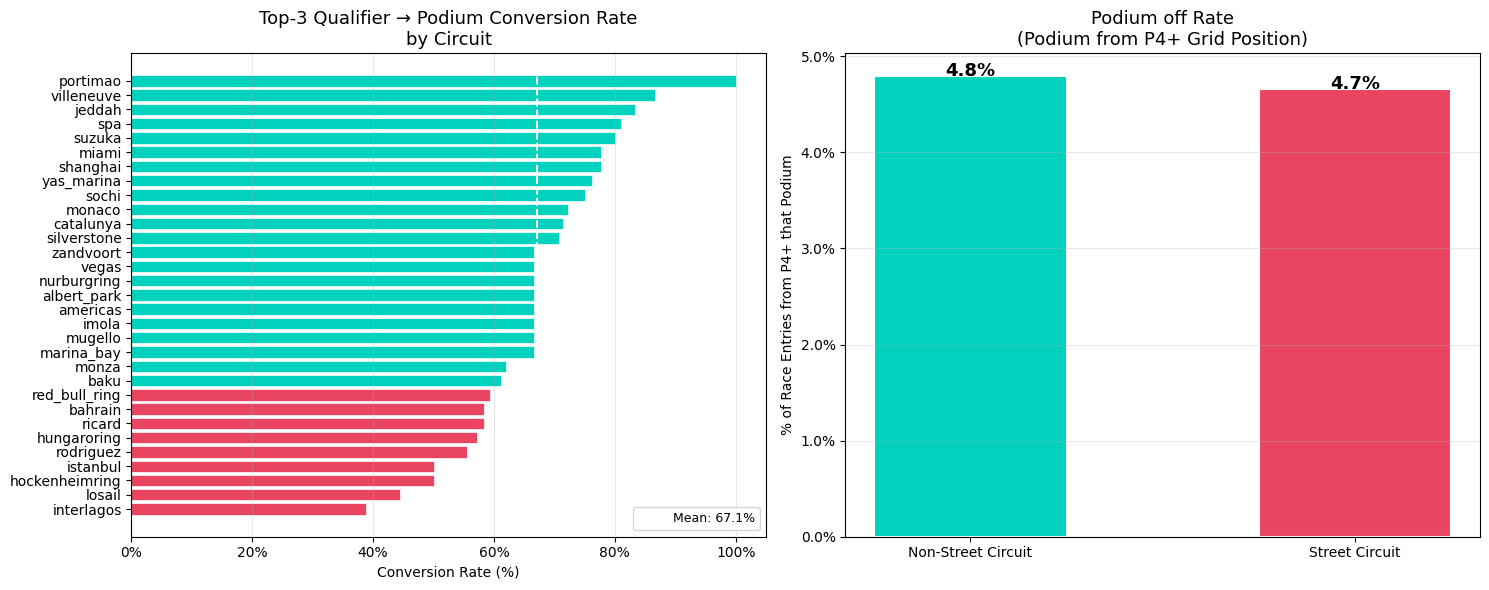

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Podium rate for TOP 3 qualifiers at each circuit (how often do they convert?)
top3_qual = master[master['qual_position'] <= 3].copy()
circuit_conversion = (top3_qual.groupby('circuitRef')['podium'].mean().sort_values().reset_index())
circuit_conversion.columns = ['circuit', 'conversion_rate']

colors_c = ['#e94560' if r < 0.6 else '#00D2BE' for r in circuit_conversion['conversion_rate']]

axes[0].barh(circuit_conversion['circuit'], circuit_conversion['conversion_rate'] * 100, color=colors_c, edgecolor='white', linewidth=0.5)
axes[0].axvline(circuit_conversion['conversion_rate'].mean() * 100, color='white', linestyle='--', linewidth=1.5, label=f"Mean: {circuit_conversion['conversion_rate'].mean():.1%}")
axes[0].set_title('Top-3 Qualifier → Podium Conversion Rate\nby Circuit', fontsize=13)
axes[0].set_xlabel('Conversion Rate (%)')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend(fontsize=9)
axes[0].grid(axis='x', alpha=0.3)

# Street vs non-street podium upset rate
off = master.copy()
off['is_upset'] = ((off['podium']==1) & (off['grid'] > 3)).astype(int)
off_type = off.groupby('is_street_circuit')['is_upset'].mean() * 100

street_labels = ['Non-Street Circuit', 'Street Circuit']
off_colors  = ['#00D2BE', '#e94560']
axes[1].bar(street_labels, off_type.values, color=off_colors, edgecolor='white', linewidth=1.5, width=0.5)
for i, val in enumerate(off_type.values):
    axes[1].text(i, val, f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')

axes[1].set_title('Podium off Rate\n(Podium from P4+ Grid Position)', fontsize=13)
axes[1].set_ylabel('% of Race Entries from P4+ that Podium')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()

### 4.5 Season Dominance Heatmap

A heatmap of average finish position per driver per year

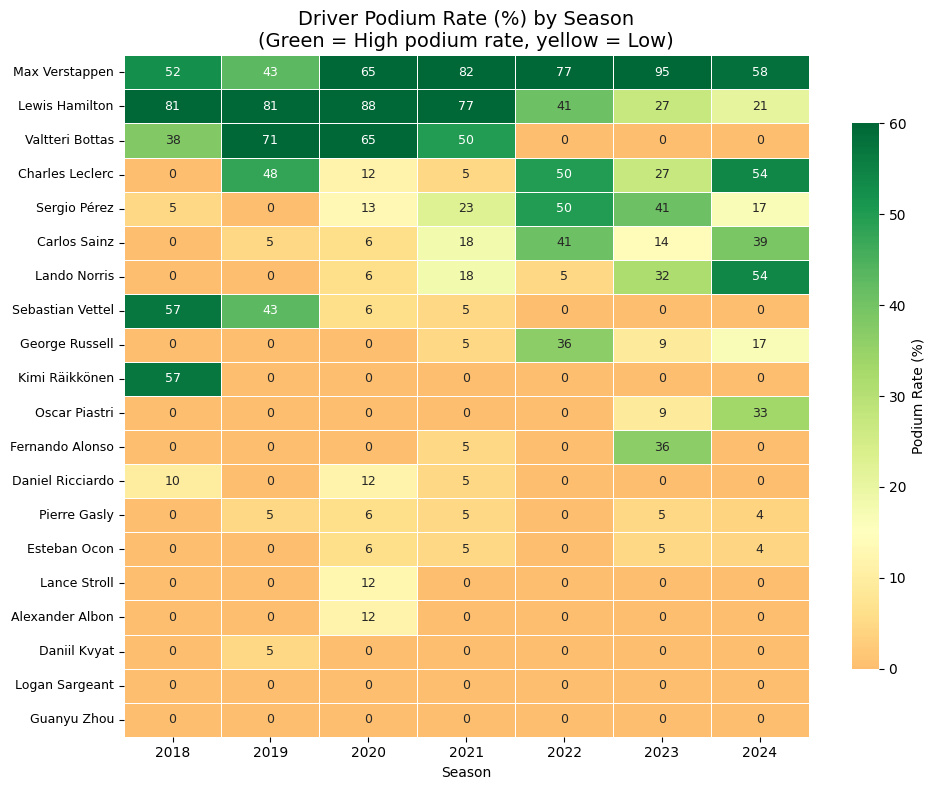

In [102]:
# Only include drivers with 5+ races across all seasons
active_drivers = (master.groupby('driver_name').size().loc[lambda x: x >= 15].index.tolist())

heatmap_data = (master[master['driver_name'].isin(active_drivers)].groupby(['driver_name','year'])['podium'].mean().unstack(fill_value=0) * 100)

# Sort by total podium rate descending
heatmap_data['total'] = heatmap_data.mean(axis=1)
heatmap_data = heatmap_data.sort_values('total', ascending=False).drop(columns='total')
heatmap_data = heatmap_data.head(20)  # top 20 drivers

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_data, ax=ax,
            cmap='RdYlGn', center=15, vmin=0, vmax=60,
            annot=True, fmt='.0f', linewidths=0.5,
            annot_kws={'size': 9},
            cbar_kws={'label': 'Podium Rate (%)', 'shrink': 0.8})

ax.set_title('Driver Podium Rate (%) by Season\n'
             '(Green = High podium rate, yellow = Low)', fontsize=14)
ax.set_xlabel('Season')
ax.set_ylabel('')
plt.setp(ax.get_xticklabels(), fontsize=10)
plt.setp(ax.get_yticklabels(), fontsize=9)
plt.tight_layout()

### 4.6 Qualifying Session vs Podium

Does reaching Q3 actually separate podium contenders from the rest?

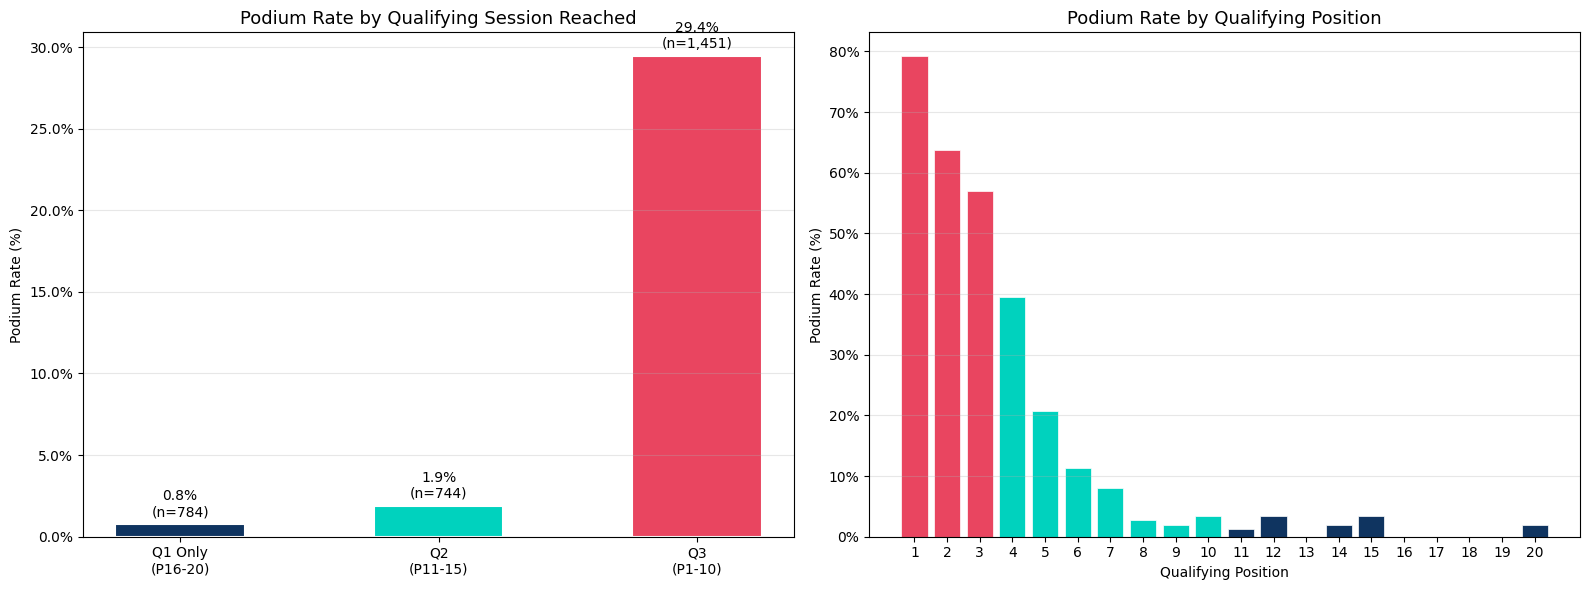

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Podium rate by qualifying session reached
qs_labels = {0: 'Q1 Only\n(P16-20)', 1: 'Q2\n(P11-15)', 2: 'Q3\n(P1-10)'}
qs_podium = master.groupby('qual_session')['podium'].agg(['mean','count'])
qs_podium.index = [qs_labels.get(i, str(i)) for i in qs_podium.index]

bar_colors_qs = ['#0f3460', '#00D2BE', '#e94560']
bars = axes[0].bar(qs_podium.index, qs_podium['mean'] * 100, color=bar_colors_qs, edgecolor='white', linewidth=1.5, width=0.5)
for bar, (_, row) in zip(bars, qs_podium.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{row['mean']:.1%}\n(n={int(row['count']):,})",
                 ha='center', fontsize=10)
axes[0].set_title('Podium Rate by Qualifying Session Reached', fontsize=13)
axes[0].set_ylabel('Podium Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].grid(axis='y', alpha=0.3)

# Podium rate by qual position (P1-P20)
qual_podium = (master.groupby('qual_position')['podium'].mean().reset_index())
qual_podium = qual_podium[qual_podium['qual_position'] <= 20]
bar_cols_q = ['#e94560' if p <= 3 else '#00D2BE' if p <= 10 else '#0f3460' for p in qual_podium['qual_position']]

axes[1].bar(qual_podium['qual_position'], qual_podium['podium'] * 100, color=bar_cols_q, edgecolor='white', linewidth=0.5)
axes[1].set_title('Podium Rate by Qualifying Position', fontsize=13)
axes[1].set_xlabel('Qualifying Position')
axes[1].set_ylabel('Podium Rate (%)')
axes[1].set_xticks(range(1, 21))
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()

### 4.7 Championship Context: Points Gap vs Podium

Drivers leading the championship tend to be the strongest

/tmp/ipython-input-212/2099420380.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot([no_podium_pts, podium_pts],


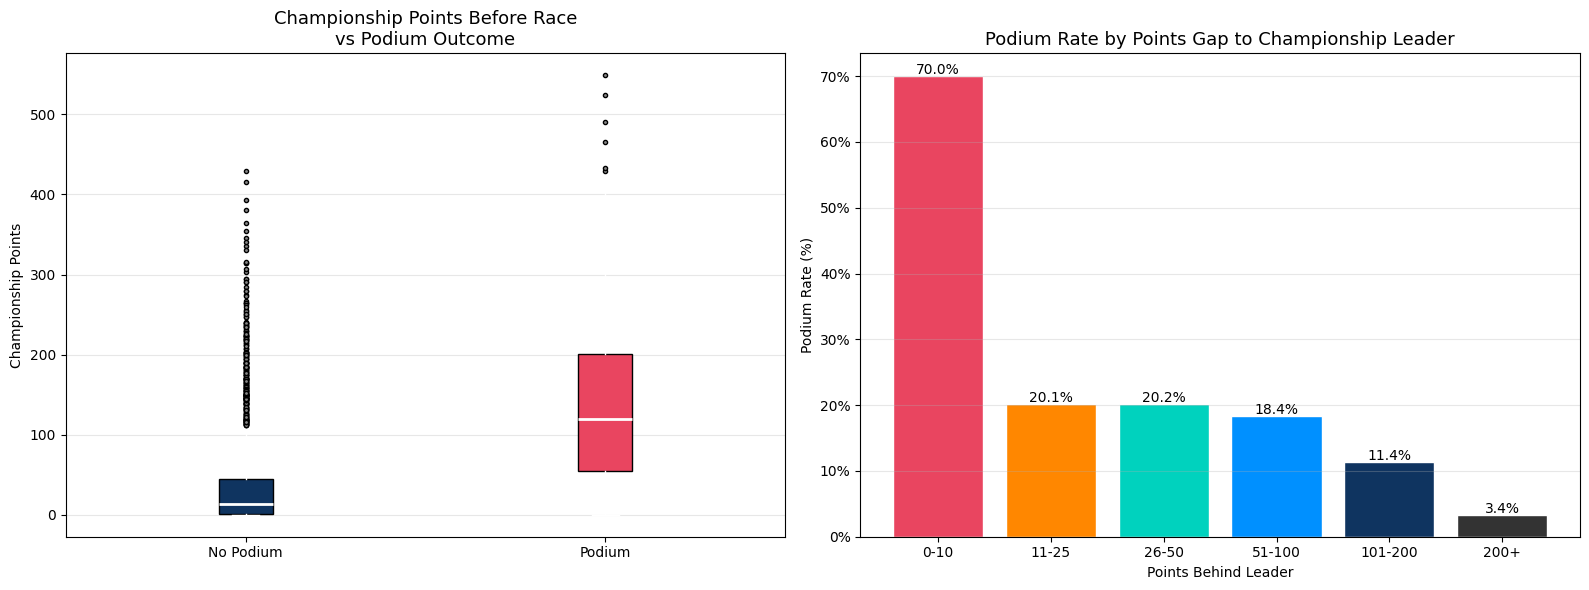

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

podium_pts    = master[master['podium']==1]['champ_points_before']
no_podium_pts = master[master['podium']==0]['champ_points_before']

bp = axes[0].boxplot([no_podium_pts, podium_pts],
                      labels=['No Podium', 'Podium'],
                      patch_artist=True,
                      medianprops=dict(color='white', linewidth=2),
                      whiskerprops=dict(color='white'),
                      capprops=dict(color='white'),
                      flierprops=dict(markerfacecolor='#888888', markersize=3))
bp['boxes'][0].set_facecolor('#0f3460')
bp['boxes'][1].set_facecolor('#e94560')
axes[0].set_title('Championship Points Before Race\nvs Podium Outcome', fontsize=13)
axes[0].set_ylabel('Championship Points')
axes[0].grid(axis='y', alpha=0.3)

master['gap_bin'] = pd.cut(master['points_gap_to_leader'], bins=[0,10,25,50,100,200,549], labels=['0-10','11-25','26-50','51-100','101-200','200+'])
gap_podium = master.groupby('gap_bin', observed=True)['podium'].mean() * 100

axes[1].bar(gap_podium.index.astype(str), gap_podium.values, color=['#e94560','#FF8700','#00D2BE','#0090FF','#0f3460','#333333'], edgecolor='white', linewidth=1)
for i, val in enumerate(gap_podium.values):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=10)
axes[1].set_title('Podium Rate by Points Gap to Championship Leader', fontsize=13)
axes[1].set_xlabel('Points Behind Leader')
axes[1].set_ylabel('Podium Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()

## Phase 5: Modelling

We compare two classifiers on the F1 podium prediction task:

1. **Logistic Regression** with Lasso (L1) and Ridge (L2) regularization
2. **Random Forest** — ensemble tree method, handles non-linearity and multicollinearity natively

### 5.1 Prepare Dataset

In [91]:
X = master[FEATURE_COLS].copy()
y = master[TARGET_COL].copy()

dates = master['date'].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Positive class (podium) rate: {y.mean():.1%}")

# Train: 2018–2022  |  Test: 2023–2024
train_mask = master['year'] <= 2022
test_mask  = master['year'] >= 2023

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"  Train (2018–2022): {X_train.shape[0]:,} rows | podium rate: {y_train.mean():.1%}")
print(f"  Test  (2023–2024): {X_test.shape[0]:,} rows  | podium rate: {y_test.mean():.1%}")


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# For Random Forest
X_train_df = X_train.copy()
X_test_df  = X_test.copy()


X shape: (2979, 23)
y shape: (2979,)
Positive class (podium) rate: 15.0%
  Train (2018–2022): 2,060 rows | podium rate: 15.0%
  Test  (2023–2024): 919 rows  | podium rate: 15.0%


### 5.2 Baseline: Naive Classifier

In [92]:
baseline_pred = (X_test['grid'] <= 3).astype(int)

baseline_metrics = {
    'Accuracy' : (baseline_pred == y_test).mean(),
    'Precision': precision_score(y_test, baseline_pred, zero_division=0),
    'Recall'   : recall_score(y_test, baseline_pred, zero_division=0),
    'F1'       : f1_score(y_test, baseline_pred, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, baseline_pred),
}

print("Naive Baseline (predict podium if grid ≤ 3):")
for metric, val in baseline_metrics.items():
    print(f"  {metric:12s}: {val:.4f}")
print("\nTarget ROC-AUC > {:.4f}".format(baseline_metrics['ROC-AUC']))

Naive Baseline (predict podium if grid ≤ 3):
  Accuracy    : 0.8966
  Precision   : 0.6569
  Recall      : 0.6522
  F1          : 0.6545
  ROC-AUC     : 0.7960

Target ROC-AUC > 0.7960


### 5.3 Logistic Regression with Lasso & Ridge

In [93]:



tscv = TimeSeriesSplit(n_splits=5)

# Lasso (L1)
lr_lasso = LogisticRegressionCV(
    Cs=10,
    cv=tscv,
    penalty='l1',
    solver='saga',
    scoring='roc_auc',
    class_weight='balanced',
    max_iter=5000,
    random_state=42,
    n_jobs=-1
)
lr_lasso.fit(X_train_scaled, y_train)

# Ridge (L2)
lr_ridge = LogisticRegressionCV(
    Cs=10,
    cv=tscv,
    penalty='l2',
    solver='saga',
    scoring='roc_auc',
    class_weight='balanced',
    max_iter=5000,
    random_state=42,
    n_jobs=-1
)
lr_ridge.fit(X_train_scaled, y_train)

print(f"\nLasso best C: {lr_lasso.C_[0]:.6f}")
print(f"Ridge best C: {lr_ridge.C_[0]:.6f}")

# How many features did Lasso zero out?
lasso_coefs = lr_lasso.coef_[0]
n_zeroed = (np.abs(lasso_coefs) < 1e-6).sum()
print(f"\nLasso zeroed out {n_zeroed}/{len(FEATURE_COLS)} features")


Lasso best C: 0.359381
Ridge best C: 0.046416

Lasso zeroed out 4/23 features


### 5.4 Random Forest with Hyperparameter Tuning

In [94]:
print("Tuning Random Forest hyperparameters...")

param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 4, 8],
    'max_features'     : ['sqrt', 'log2', 0.5],
    'class_weight'     : ['balanced', 'balanced_subsample'],
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist,
    n_iter=40,
    cv=tscv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_search.fit(X_train_df, y_train)

rf_best = rf_search.best_estimator_;

print(f"\nBest RF parameters:")
for param, val in rf_search.best_params_.items():
    print(f"   {param:22s}: {val}")
print(f"\nBest CV ROC-AUC: {rf_search.best_score_:.4f}")

Tuning Random Forest hyperparameters...

Best RF parameters:
   n_estimators          : 100
   min_samples_split     : 10
   min_samples_leaf      : 8
   max_features          : log2
   max_depth             : 3
   class_weight          : balanced

Best CV ROC-AUC: 0.9399


### 5.5 Cross-Validation Performance Comparison

In [95]:
print("Running TimeSeriesSplit cross-validation (5 folds)")

scoring_metrics = ['roc_auc', 'f1', 'precision', 'recall', 'accuracy']

# Lasso CV
cv_lasso = cross_validate(
    LogisticRegressionCV(Cs=[lr_lasso.C_[0]], cv=3, penalty='l1',
                          solver='saga', scoring='roc_auc',
                          class_weight='balanced', max_iter=5000, random_state=42),
    X_train_scaled, y_train,
    cv=tscv, scoring=scoring_metrics, n_jobs=-1
)

# Ridge CV
cv_ridge = cross_validate(
    LogisticRegressionCV(Cs=[lr_ridge.C_[0]], cv=3, penalty='l2',
                          solver='saga', scoring='roc_auc',
                          class_weight='balanced', max_iter=5000, random_state=42),
    X_train_scaled, y_train,
    cv=tscv, scoring=scoring_metrics, n_jobs=-1
)

# Random Forest CV
cv_rf = cross_validate(
    rf_best,
    X_train_df, y_train,
    cv=tscv, scoring=scoring_metrics, n_jobs=-1
)

results_cv = {}
for name, cv_result in [('Lasso LR', cv_lasso), ('Ridge LR', cv_ridge), ('Random Forest', cv_rf)]:
    results_cv[name] = {
        metric: f"{cv_result[f'test_{metric}'].mean():.4f} ± {cv_result[f'test_{metric}'].std():.4f}"
        for metric in scoring_metrics
    }

cv_df = pd.DataFrame(results_cv).T
print("\nCross-Validation Results (mean ± std across 5 folds):")
print(cv_df.to_string())

Running TimeSeriesSplit cross-validation (5 folds)

Cross-Validation Results (mean ± std across 5 folds):
                       roc_auc               f1        precision           recall         accuracy
Lasso LR       0.9306 ± 0.0154  0.6489 ± 0.0634  0.5106 ± 0.0736  0.9022 ± 0.0513  0.8513 ± 0.0382
Ridge LR       0.9319 ± 0.0124  0.6514 ± 0.0440  0.5094 ± 0.0485  0.9100 ± 0.0591  0.8536 ± 0.0248
Random Forest  0.9399 ± 0.0087  0.6783 ± 0.0225  0.5454 ± 0.0210  0.8983 ± 0.0383  0.8729 ± 0.0090


### 5.6 Test Set Evaluation

Final evaluation on held-out 2023–2024 data.

In [96]:
def evaluate_model(name, model, X_test_input, y_test, threshold=0.5):
    y_prob = model.predict_proba(X_test_input)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        'ROC-AUC'  : roc_auc_score(y_test, y_prob),
        'F1'       : f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, zero_division=0),
        'Accuracy' : (y_pred == y_test).mean(),
    }
    return metrics, y_prob, y_pred

lasso_metrics, lasso_prob, lasso_pred = evaluate_model('Lasso',  lr_lasso, X_test_scaled, y_test)
ridge_metrics, ridge_prob, ridge_pred = evaluate_model('Ridge',  lr_ridge, X_test_scaled, y_test)
rf_metrics,    rf_prob,    rf_pred    = evaluate_model('RF',     rf_best,  X_test_df,     y_test)

# Print comparison table
print("=" * 65)
print(f"{'Metric':<12} {'Naive Baseline':>16} {'Lasso LR':>12} {'Ridge LR':>12} {'Random Forest':>14}")
print("=" * 65)
for metric in ['ROC-AUC', 'F1', 'Precision', 'Recall', 'Accuracy']:
    base_val  = baseline_metrics[metric]
    lasso_val = lasso_metrics[metric]
    ridge_val = ridge_metrics[metric]
    rf_val    = rf_metrics[metric]
    best = max(lasso_val, ridge_val, rf_val)
    print(f"{metric:<12} {base_val:>16.4f} {lasso_val:>12.4f} {ridge_val:>12.4f} "
          f"{rf_val:>14.4f}{'  ← best' if rf_val == best else ''}")
print("=" * 65)

Metric         Naive Baseline     Lasso LR     Ridge LR  Random Forest
ROC-AUC                0.7960       0.9260       0.9227         0.9344  ← best
F1                     0.6545       0.5985       0.5947         0.6139  ← best
Precision              0.6569       0.4505       0.4444         0.4662  ← best
Recall                 0.6522       0.8913       0.8986         0.8986  ← best
Accuracy               0.8966       0.8205       0.8161         0.8303  ← best


### 5.8 Confusion Matrices

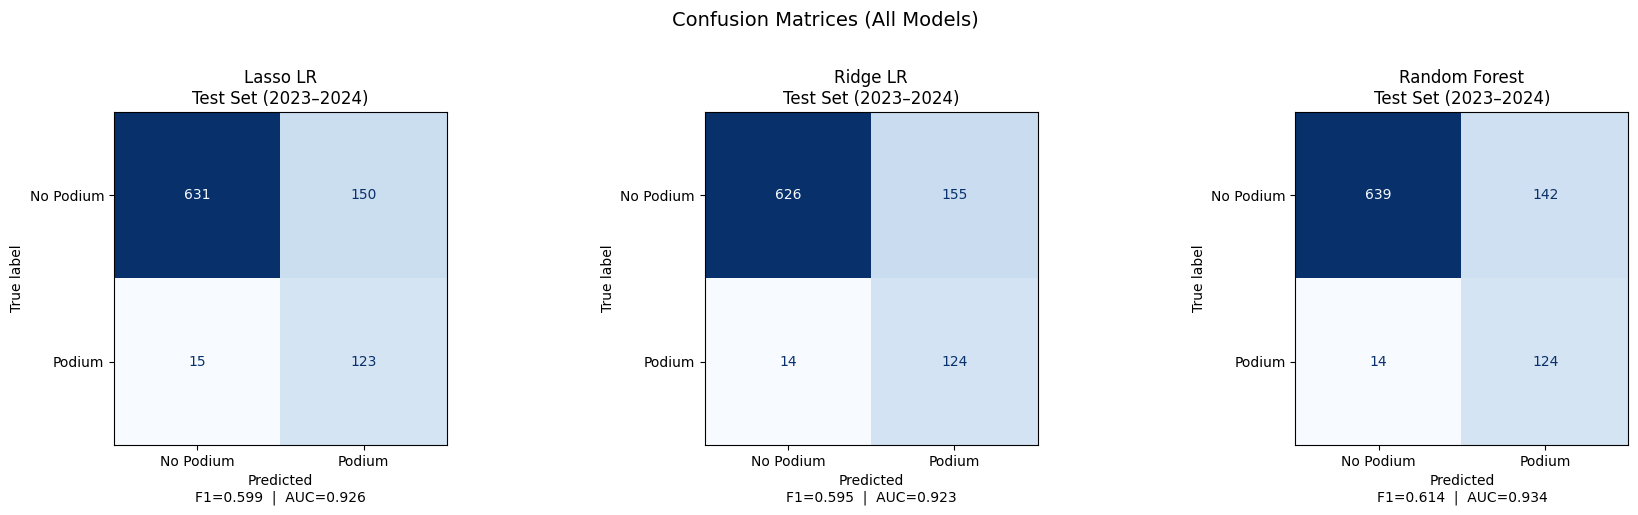

In [97]:


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred, color) in zip(axes, [
    ('Lasso LR',     lasso_pred, '#00D2BE'),
    ('Ridge LR',     ridge_pred, '#FF8700'),
    ('Random Forest',rf_pred,    '#e94560'),
]):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Podium', 'Podium'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nTest Set (2023–2024)', fontsize=12)

    f1  = f1_score(y_test, pred)
    auc = roc_auc_score(y_test,
          lr_lasso.predict_proba(X_test_scaled)[:,1] if 'Lasso' in name
     else lr_ridge.predict_proba(X_test_scaled)[:,1] if 'Ridge' in name
     else rf_best.predict_proba(X_test_df)[:,1])
    ax.set_xlabel(f'Predicted\nF1={f1:.3f}  |  AUC={auc:.3f}', fontsize=10)

plt.suptitle('Confusion Matrices (All Models)', fontsize=14, y=1.02)
plt.tight_layout()


### 5.9 Feature Importance & Logistic Regression Coefficients



Top 10 RF features:
qual_session               0.0284
driver_form_5              0.0330
constructor_form_5         0.0461
constructor_reliability    0.0556
con_pos_before             0.0569
champ_pos_before           0.0880
grid                       0.1221
qual_gap_to_pole_pct       0.1354
grid_x_champ               0.1710
qual_position              0.1717

Top Lasso coefficients (non-zero):
qual_session              -1.7543
grid_x_champ              -1.4043
qual_position             -0.9355
qual_gap_to_pole_pct      -0.6274
grid                      -0.5573
points_gap_to_leader      -0.3745
constructor_reliability   -0.2857
constructor_form_5        -0.1494
is_high_altitude          -0.0602
driver_circuit_avg        -0.0576
driver_form_5             -0.0488
is_street_circuit         -0.0231
age                        0.0064
champ_pos_before           0.0090
drs_zones                  0.0483
champ_wins_before          0.0682
con_pos_before             0.1076
champ_points_before      

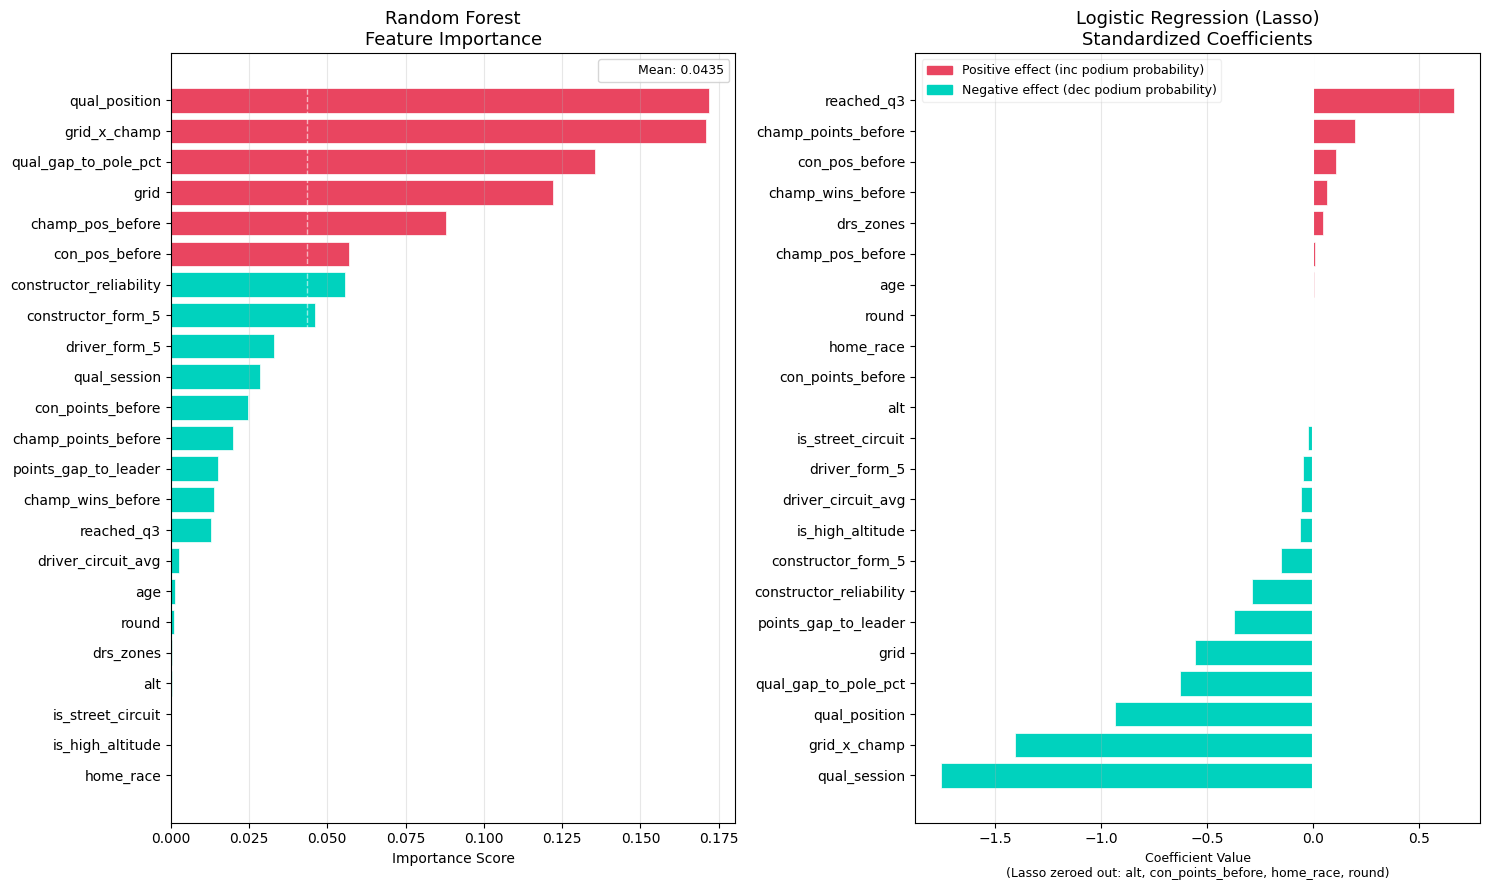

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(15, 9))

# Random Forest Feature Importance
rf_importances = pd.Series(rf_best.feature_importances_, index=FEATURE_COLS)
rf_importances = rf_importances.sort_values(ascending=True)

colors_rf = ['#e94560' if v >= rf_importances.quantile(0.75) else '#00D2BE' for v in rf_importances.values]
axes[0].barh(rf_importances.index, rf_importances.values, color=colors_rf, edgecolor='white', linewidth=0.5)
axes[0].set_title('Random Forest\nFeature Importance', fontsize=13)
axes[0].set_xlabel('Importance Score')
axes[0].grid(axis='x', alpha=0.3)
axes[0].axvline(rf_importances.mean(), color='white', linestyle='--', linewidth=1, alpha=0.6, label=f"Mean: {rf_importances.mean():.4f}")
axes[0].legend(fontsize=9)

# Lasso Coefficients
lasso_coef = pd.Series(lr_lasso.coef_[0], index=FEATURE_COLS).sort_values()
colors_lr = ['#e94560' if v > 0 else '#00D2BE' for v in lasso_coef.values]

axes[1].barh(lasso_coef.index, lasso_coef.values, color=colors_lr, edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='white', linewidth=1.5)
axes[1].set_title('Logistic Regression (Lasso)\nStandardized Coefficients', fontsize=13)
axes[1].set_xlabel('Coefficient Value')
axes[1].grid(axis='x', alpha=0.3)

# Mark zeroed-out features
zeroed = lasso_coef[np.abs(lasso_coef) < 1e-6].index.tolist()
if zeroed:
    axes[1].set_xlabel(f'Coefficient Value\n(Lasso zeroed out: {", ".join(zeroed)})', fontsize=9)



red_p  = Patch(color='#e94560', label='Positive effect (inc podium probability)')
teal_p = Patch(color='#00D2BE', label='Negative effect (dec podium probability)')
axes[1].legend(handles=[red_p, teal_p], fontsize=9, framealpha=0.3)

plt.tight_layout()

print("\nTop 10 RF features:")
print(rf_importances.tail(10).round(4).to_string())
print("\nTop Lasso coefficients (non-zero):")
non_zero = lasso_coef[np.abs(lasso_coef) > 1e-6].sort_values()
print(non_zero.round(4).to_string())

### 5.10 Probability Calibration Check

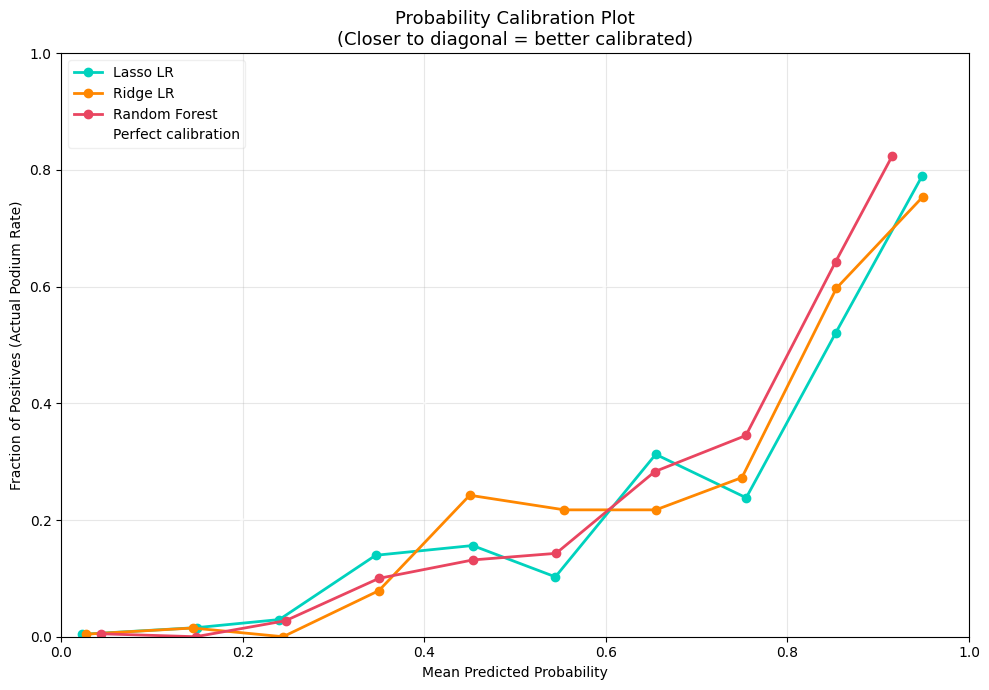

In [100]:
models_eval = [
    ('Lasso LR',     lasso_prob, '#00D2BE'),
    ('Ridge LR',     ridge_prob, '#FF8700'),
    ('Random Forest',rf_prob,    '#e94560'),
]

fig, ax = plt.subplots(figsize=(10, 7))

for name, prob, color in models_eval:
    fraction_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10)
    ax.plot(mean_pred, fraction_pos, marker='o', linewidth=2,
            color=color, label=name, markersize=6)

ax.plot([0,1],[0,1], 'white', linestyle='--', linewidth=1.5, alpha=0.7, label='Perfect calibration')
ax.set_title('Probability Calibration Plot\n(Closer to diagonal = better calibrated)', fontsize=13)
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (Actual Podium Rate)')
ax.legend(fontsize=10, framealpha=0.3)
ax.grid(alpha=0.3)
ax.set_xlim([0,1])
ax.set_ylim([0,1])

plt.tight_layout()

### 5.11 Per-Race Prediction: 2024 Season Walkthrough

In [101]:
races_2024 = master[master['year'] == 2024].copy()
races_2024['rf_prob'] = rf_best.predict_proba(races_2024[FEATURE_COLS])[:, 1]
races_2024['lasso_prob'] = lr_lasso.predict_proba(scaler.transform(races_2024[FEATURE_COLS]))[:, 1]

# did our top-3 probability picks match actual podium?
race_results = []
for race_id in races_2024['raceId'].unique():
    race = races_2024[races_2024['raceId'] == race_id].copy()
    race_name = race['name'].iloc[0]

    actual_podium  = set(race[race['podium']==1]['driver_name'].tolist())
    rf_top3        = set(race.nlargest(3, 'rf_prob')['driver_name'].tolist())
    lasso_top3     = set(race.nlargest(3, 'lasso_prob')['driver_name'].tolist())

    rf_hits    = len(actual_podium & rf_top3)
    lasso_hits = len(actual_podium & lasso_top3)

    race_results.append({
        'Race'         : race_name,
        'Actual Podium': ', '.join(sorted(actual_podium)),
        'RF Top 3'     : ', '.join(sorted(rf_top3)),
        'RF Hits'      : rf_hits,
        'Lasso Top 3'  : ', '.join(sorted(lasso_top3)),
        'Lasso Hits'   : lasso_hits,
    })

race_df = pd.DataFrame(race_results)
print("2024 Season — Per-Race Podium Prediction (correct picks out of 3):")
print(race_df[['Race','Actual Podium','RF Hits','Lasso Hits']].to_string(index=False))
print(f"\nRF    avg hits per race: {race_df['RF Hits'].mean():.2f}/3  "
      f"({race_df['RF Hits'].mean()/3:.1%} hit rate)")
print(f"Lasso avg hits per race: {race_df['Lasso Hits'].mean():.2f}/3  "
      f"({race_df['Lasso Hits'].mean()/3:.1%} hit rate)")

2024 Season — Per-Race Podium Prediction (correct picks out of 3):
                     Race                                  Actual Podium  RF Hits  Lasso Hits
       Bahrain Grand Prix     Carlos Sainz, Max Verstappen, Sergio Pérez        1           1
 Saudi Arabian Grand Prix  Charles Leclerc, Max Verstappen, Sergio Pérez        3           3
    Australian Grand Prix    Carlos Sainz, Charles Leclerc, Lando Norris        1           1
      Japanese Grand Prix     Carlos Sainz, Max Verstappen, Sergio Pérez        2           2
       Chinese Grand Prix     Lando Norris, Max Verstappen, Sergio Pérez        3           3
         Miami Grand Prix  Charles Leclerc, Lando Norris, Max Verstappen        2           2
Emilia Romagna Grand Prix  Charles Leclerc, Lando Norris, Max Verstappen        3           3
        Monaco Grand Prix   Carlos Sainz, Charles Leclerc, Oscar Piastri        3           3
      Canadian Grand Prix   George Russell, Lando Norris, Max Verstappen        3      

# Report

## Data Preparation

The raw dataset covers F1 history from 1950. Analysis was restricted to **2018–2024** (2,979 race entries, avg. 20 drivers per race) to reflect the modern hybrid-engine era and avoid structural regime changes from earlier decades.

| Season | Races |
|--------|-------|
| 2018 | 21 |
| 2019 | 21 |
| 2020 | 17 |
| 2021 | 22 |
| 2022 | 22 |
| 2023 | 22 |
| 2024 | 24 |

### Target Variable

The podium flag (`positionOrder <= 3`) is inherently imbalanced at a **15% positive rate** (447 podiums / 2,979 entries), giving a class ratio of roughly 1:6. This imbalance is expected and reflects reality only 3 of 20 drivers can podium per race. All models were trained with `class_weight='balanced'` to compensate.

## Feature Engineering

### Qualifying Gap to Pole (`qual_gap_to_pole_pct`)

Each driver's best qualifying time was normalised as a percentage gap to the pole-sitter's time within the same race:

```
qual_gap_to_pole_pct = (driver_time − pole_time) / pole_time × 100
```

This makes lap times comparable across circuits. The distribution spans 0–5% for competitive runners, with outliers at 45% for very slow drivers or atypical sessions. Values were clipped at 0 (no negative gaps retained)

### Driver Form (`driver_form_5`, `driver_form_3`)

An **Exponentially Weighted Moving Average** (span=5) of a driver's `positionOrder` over their last five races, computed per driver chronologically. Lower values indicate better recent form. Hamilton's 2021 average of 3.41 confirms the metric is sensible. A rolling 3-race mean (`driver_form_3`) was also computed but ultimately excluded from the final feature set.

### Constructor Form & Reliability

- `constructor_form_5`: EWMA (span=5) of constructor-level `positionOrder`, capturing team momentum
- `constructor_reliability`: Rolling 10-race DNF rate per constructor

Red Bull 2023 correctly returned a reliability score of **0.059** (near-zero DNF rate) and form score of **3.58**, validating both metrics.

### Driver Track Affinity (`driver_circuit_avg`)

Historical average `positionOrder` per driver-circuit pair, using only prior visits (`.shift(1)`). This captures circuit-specific strengths such as Verstappen's dominance at Vegas (avg 1.09) and Hamilton's at Istanbul (1.25) and Sochi (1.35).

### Track Type Features

Three binary/ordinal track characteristics were encoded:
- `is_street_circuit`: Monaco, Baku, Singapore, Jeddah, Miami, Vegas, Losail (19.5% of entries)
- `is_high_altitude`: Circuits above 1,000m elevation (4.0% of entries)
- `drs_zones`: Number of DRS activation zones per circuit (1–4), mapped manually from circuit references

### Home Race (`home_race`)

A nationality-to-country lookup flagged races where the driver's nationality matched the host country. Home race entries represent 3.2% of the dataset. The podium rate at home races is **18.8%** vs. **14.9%** away — a +3.87 percentage point home advantage. This is suggestive but the feature has weak model importance (Lasso coefficient near zero), likely because home-race drivers are already captured by their championship standing.

### Winning Mindset (`grid_x_champ`, `points_gap_to_leader`)

Two interaction features capturing competitive context:
- `grid_x_champ = grid × champ_pos_before`: Low values indicate a front-row driver who is also high in the championship — the profile of a dominant season. This became the **second most important feature** in the Random Forest.
- `points_gap_to_leader`: Points deficit to the current championship leader before the race. Drivers within 10 points of the leader have a podium rate of **70%**; those 200+ points behind drop to **3.4%**.

23 features were selected for modelling:

| Group | Features |
|-------|----------|
| Qualifying & Grid | `grid`, `qual_position`, `qual_gap_to_pole_pct`, `qual_session`, `reached_q3` |
| Driver Form | `driver_form_5`, `driver_circuit_avg`, `age` |
| Constructor | `constructor_form_5`, `constructor_reliability` |
| Championship | `champ_points_before`, `champ_pos_before`, `champ_wins_before`, `con_points_before`, `con_pos_before` |
| Track | `is_street_circuit`, `is_high_altitude`, `drs_zones`, `alt` |
| Contextual | `home_race`, `round`, `grid_x_champ`, `points_gap_to_leader` |

---

## Exploratory Data Analysis

### Driver & Constructor Dominance (2018–2024)

**Max Verstappen** leads with 101 podiums across the period, followed by Lewis Hamilton (85) and Valtteri Bottas (45). The constructor podium share chart reveals a clear shift in dominance: Mercedes controlled 2018–2021, Ferrari and Red Bull shared 2022, and **Red Bull monopolised 2022–2023** before McLaren and Ferrari made inroads in 2024.

### Grid Position vs. Podium Rate

Grid position is the single strongest raw predictor of podium outcome. Starting from P1, P2, or P3 gives podium rates of **~80%, ~60%, and ~55%** respectively. The probability falls sharply from P4 onward. Cumulatively, 50% of all podiums across 2018–2024 come from cars starting in positions 1–3, and 90% from positions 1–7. No driver starting from P16 or beyond achieved a podium in this dataset.

### Driver & Constructor Form Separation

The distribution plots for `driver_form_5` and `constructor_form_5` show clear separation between podium and non-podium finishers:
- **Podium mean (driver form): 5.38** vs. Non-podium mean: 11.32
- **Podium mean (constructor form): 5.70** vs. Non-podium mean: 11.31

The `qual_gap_to_pole_pct` distribution is similarly separated (0.46 vs 2.04), confirming that qualifying pace strongly reflects race competitiveness.

### Season Dominance Heatmap

The per-driver, per-season podium rate heatmap confirms known narratives: Hamilton's 81–88% podium rate in 2018–2020, Verstappen's rise from 43% in 2019 to 82% in 2021 and 95% in 2023. Leclerc and Norris show strong 2024 rates (54%), consistent with Ferrari and McLaren's competitive resurgence.

### Qualifying Session vs. Podium Rate

Drivers who reach Q3 podium at a **29.4% rate**, compared to 1.9% for Q2-eliminated drivers and 0.8% for Q1-eliminated. The step change between Q2 and Q3 is dramatic and explains why `qual_session` and `reached_q3` are among the highest-correlation features in the dataset (r = +0.36 and +0.39 respectively with the podium target).

### Championship Points Gap vs. Podium

The box-plot shows podium finishers enter a race with a median championship points tally roughly triple that of non-podium finishers, confirming that accumulated momentum (which reflects sustained car and driver quality) is a powerful predictor. The points gap analysis reinforces this — drivers within 10 points of the championship lead podium at 70%, collapsing to 3.4% for those 200+ points adrift.

---

## Modelling

### Methodology

**Train/test split:** A **temporal split** was usedtraining on 2018–2022 (2,060 rows) and testing on 2023–2024 (919 rows). This is the methodologically correct approach for time-series sports data, as it prevents any future information from influencing model training and evaluates genuine out-of-sample generalization.

**Scaling:** Features were standardised using `StandardScaler` fit on the training set only, then applied to the test set. Raw (unscaled) features were passed directly to the Random Forest.

**Baseline:** A naive classifier that predicts podium for any driver starting from grid positions 1–3 achieves ROC-AUC = 0.796. All trained models must exceed this.

### Models Evaluated

**Logistic Regression with L1 (Lasso):** Cross-validated C selection over 10 values using `TimeSeriesSplit(n_splits=5)`. Best C = 0.359. Lasso automatically zeroed out 4 of 23 features (`alt`, `con_points_before`, `home_race`, `round`), performing implicit feature selection.

**Logistic Regression with L2 (Ridge):** Same setup, best C = 0.046 (stronger regularisation). Retains all features with shrinkage.

**Random Forest Classifier:** Hyperparameters tuned via `RandomizedSearchCV` (40 iterations, TimeSeriesSplit). Best configuration: 100 trees, max depth 3, min samples leaf 8, log2 features, balanced class weight. The shallow depth (3) acts as a strong regulariser preventing overfitting.

### Cross-Validation Results (2018–2022, 5-fold TimeSeriesSplit)

| Model | ROC-AUC | F1 | Precision | Recall | Accuracy |
|-------|---------|-----|-----------|--------|----------|
| Lasso LR | 0.9306 ± 0.0154 | 0.6489 ± 0.0634 | 0.5106 ± 0.0736 | 0.9022 ± 0.0513 | 0.8513 ± 0.0382 |
| Ridge LR | 0.9319 ± 0.0124 | 0.6514 ± 0.0440 | 0.5094 ± 0.0485 | 0.9100 ± 0.0591 | 0.8536 ± 0.0248 |
| Random Forest | **0.9399 ± 0.0087** | **0.6783 ± 0.0225** | **0.5454 ± 0.0210** | 0.8983 ± 0.0383 | **0.8729 ± 0.0090** |

The Random Forest achieves the best score on all metrics.

### Test Set Results (2023–2024 Holdout)

| Metric | Naive Baseline | Lasso LR | Ridge LR | Random Forest |
|--------|---------------|----------|----------|---------------|
| ROC-AUC | 0.7960 | 0.9260 | 0.9227 | **0.9344** |
| F1 | 0.6545 | 0.5985 | 0.5947 | **0.6139** |
| Precision | 0.6569 | 0.4505 | 0.4444 | **0.4662** |
| Recall | 0.6522 | 0.8913 | 0.8986 | **0.8986** |
| Accuracy | **0.8966** | 0.8205 | 0.8161 | 0.8303 |

All three trained models substantially outperform the naive baseline on ROC-AUC (+13 percentage points), demonstrating that the engineered features add genuine predictive signal beyond grid position alone. The **Random Forest is the best overall model** with ROC-AUC = 0.934 and Average Precision = 0.730.

### Confusion Matrix Summary (Random Forest)

On the 919-row test set:
- **True Negatives:** 639 (correctly predicted no podium)
- **False Positives:** 142 (predicted podium, driver did not podium)
- **False Negatives:** 14 (missed actual podium finishers)
- **True Positives:** 124 (correctly predicted podium)

The model misses very few actual podiums (14 out of 138) these are likely genuine upsets where a front-running car suffered a mechanical failure or collision not foreseeable from pre-race features.

---

## Feature Importance Analysis

### Random Forest

| Rank | Feature | Importance |
|------|---------|-----------|
| 1 | `qual_position` | 0.1717 |
| 2 | `grid_x_champ` | 0.1710 |
| 3 | `qual_gap_to_pole_pct` | 0.1354 |
| 4 | `grid` | 0.1221 |
| 5 | `champ_pos_before` | 0.0880 |
| 6 | `con_pos_before` | 0.0569 |
| 7 | `constructor_reliability` | 0.0556 |
| 8 | `constructor_form_5` | 0.0461 |
| 9 | `driver_form_5` | 0.0330 |
| 10 | `qual_session` | 0.0284 |

The top 4 features (`qual_position`, `grid_x_champ`, `qual_gap_to_pole_pct`, `grid`) together account for **61% of total importance**, all directly measuring qualifying and starting performance. The interaction term `grid_x_champ` is the second most important feature, validating the design decision to combine grid position with championship standing.

Track-level features (`is_street_circuit`, `is_high_altitude`, `drs_zones`, `alt`, `home_race`) scored near zero importance in the Random Forest, consistent with their near-zero correlation with the podium target found during EDA.

### Logistic Regression (Lasso Coefficients)

The largest negative coefficients (increasing podium probability as the feature decreases) are `qual_session` (−1.754), `grid_x_champ` (−1.404), and `qual_position` (−0.936), aligning with the Random Forest rankings.

The Lasso automatically **zeroed out four features**: `alt`, `con_points_before`, `home_race`, and `round`, confirming they carry no independent predictive power once the other features are accounted for.

The positive coefficient on `reached_q3` (+0.666) and `champ_points_before` (+0.200) makes intuitive sense: reaching Q3 is associated with higher podium probability, and accumulated championship points proxy sustained competitiveness.

---

## Conclusions

### Key Findings

**Qualifying is the dominant predictor.** Qualifying position, qualifying gap to pole, and qualifying session reached collectively explain the majority of predictive variance. A driver who reaches Q3 is ~37 times more likely to podium than one eliminated in Q1.

**Grid position and championship context interact powerfully.** The engineered interaction feature `grid_x_champ` ranks second in the Random Forest, confirming that championship-leading drivers who also qualify at the front are the dominant force in podium prediction.

**Team quality matters as much as driver quality.** Constructor position, constructor form, and constructor reliability all appear in the top 10 features. In F1, car performance is the primary determinant of race outcomes, with driver skill a secondary differentiator among elite competitors.

**Track and contextual features add minimal signal.** Street circuit status, altitude, DRS zones, home race, and round number were all eliminated or near-zero weighted. This suggests that once qualifying pace and championship context are known, circuit type does not materially shift podium probability, strong cars are strong everywhere.

### Model Recommendation

The **Random Forest** is recommended as the production model, with the following profile:
- ROC-AUC = **0.934** on 2023–2024 holdout data
- Captures 90% of actual podium finishers
- More stable across cross-validation folds than logistic alternatives
- Handles non-linearity (e.g., the steep drop in podium probability from P3 to P4) natively

For applications requiring interpretability, the **Lasso Logistic Regression** is a strong alternative at 0.926 ROC-AUC with fully transparent coefficients.

### Limitations & Future Work

| Limitation | Potential Improvement |
|---|---|
| DNF classification over-counts mechanical failures | Use FIA technical regulations and official retirement reasons |
| Season-opening race standings default to zero | Carry end-of-previous-season standings forward |
| No real-time race data (weather, safety cars) | Integrate live telemetry or weather API features |
| Track features show near-zero importance | Replace with tyre compound data or sector time splits |
| New driver cold-start problem | Add a rookie flag and seed with F2 performance statistics |
| Precision only 47% | Threshold tuning or cost-sensitive learning to balance precision/recall |

